# B401 Continuous-Time Derivatives Pricing
## Take-Home Assignment, Summer Term 2026

Eberhard Karls Universität Tübingen, Faculty of Economics and Social Sciences

Daanish Muzaffar (7259472)

---
## Setup

The numerics use `numpy` and `pandas`. Black-Scholes needs `scipy.stats.norm`, the Rheinmetall prices come from `yfinance`, and the plots use `matplotlib`. Warnings are turned off so the output is easier to read.

In [53]:
# make sure every third-party library is present, installing only the missing ones
import importlib.util, sys, subprocess

required_packages = ['numpy', 'pandas', 'scipy', 'yfinance', 'matplotlib']

missing = [pkg for pkg in required_packages if importlib.util.find_spec(pkg) is None]
if missing:
    print(f'Installing missing packages: {", ".join(missing)} ...')
    for _flags in ([], ['--user'], ['--break-system-packages']):
        try:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', *missing] + _flags)
            break
        except subprocess.CalledProcessError:
            if _flags == ['--break-system-packages']:
                raise
    print('Installation complete.')
else:
    print('All dependencies satisfied.')

All dependencies satisfied.


In [54]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy.stats import norm
import yfinance as yf
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 150,'axes.spines.top': False, 'axes.spines.right': False,'axes.grid': True,'grid.alpha': 0.3,'font.size': 11})

TICKER = 'RHM.DE'  # Rheinmetall AG on XETRA

### Data Download

Prices are read from a local cache (`data/rhm_prices.csv`) so the notebook runs offline. Yahoo Finance is only called when the cache is missing. The data is dividend- and split-adjusted RHM.DE daily closes from 02 Jan 2023 to 01 Jun 2026, and from these we compute daily log-returns. Starting in 2023 leaves about 2.7 years of history before the DU2076 window opens in Sep 2025, which covers both the 30-day rolling window and the full-sample vol estimate. The end date is 2026-06-02 because yfinance treats `end` as exclusive, so the last day actually returned is 01 Jun 2026. That is also the Part 1 design date.

### Volatility Estimators

All volatility estimates are built from daily log-returns,

$$r_t = \ln\!\left(\frac{S_t}{S_{t-1}}\right)$$

Part 1's product design uses the full-sample annualised estimate (`SIGMA_CPN`),

$$\hat{\sigma}_{\text{hist}} = \sqrt{252} \cdot \operatorname{std}(r_1, r_2, \ldots, r_T)$$

with $T = 865$ daily log-returns. Part 2's daily valuation uses a 30-day rolling estimate instead,

$$\hat{\sigma}_t^{(30)} = \sqrt{252} \cdot \operatorname{std}\!\left(r_{t-29}, \ldots, r_t\right)$$

looked up with `rolling_vol_30.asof(date)` inside the pricing loop. The product design wants a stable long-run number, so it uses the full sample, while the daily pricing should track the current vol level, so it uses the short window. Part 3's Monte Carlo sits in between and uses a 252-day trailing estimate.


In [55]:
# cache-first load: prices are read from data/rhm_prices.csv so every run is
# offline and reproducible; Yahoo is only contacted if the cache is missing.
import os
CACHE_FILE = 'data/rhm_prices.csv'
REFRESH    = False   # set True to force a fresh download and overwrite the cache

if (not REFRESH) and os.path.exists(CACHE_FILE):
    prices = pd.read_csv(CACHE_FILE, index_col='Date', parse_dates=True)['Close'].dropna()
    print(f'Loaded {len(prices)} trading days from cache: {CACHE_FILE} (no API call)')
else:
    raw    = yf.download(TICKER, start='2023-01-01', end='2026-06-02', auto_adjust=True)
    prices = raw['Close'].dropna()
    if isinstance(prices, pd.DataFrame):
        prices = prices.iloc[:, 0]
    prices.name = 'Close'
    prices.index = pd.to_datetime(prices.index)
    prices.index.name = 'Date'
    prices.to_csv(CACHE_FILE, header=True)
    print(f'Downloaded {len(prices)} trading days from Yahoo Finance and cached to {CACHE_FILE}')

prices.index = pd.to_datetime(prices.index)
print(f'Range: {prices.index[0].date()} to {prices.index[-1].date()}')
print(f'Latest close: EUR {float(prices.iloc[-1]):.2f}')

log_returns = np.log(prices / prices.shift(1)).dropna()

# full-sample historical std dev, used for the Part 1 product design
SIGMA_HIST = float(log_returns.std() * np.sqrt(252))
print(f'Full-sample hist std dev (Part 1): {SIGMA_HIST:.2%}')

# 30-day rolling vol, used for the Part 2 pricing (Tasks V-VII)
rolling_vol_30 = log_returns.rolling(30).std() * np.sqrt(252)
rv_valid = rolling_vol_30.dropna()
print(f'30-day rolling vol: min={float(rv_valid.min()):.2%}  max={float(rv_valid.max()):.2%}  mean={float(rv_valid.mean()):.2%}')

Loaded 866 trading days from cache: data/rhm_prices.csv (no API call)
Range: 2023-01-02 to 2026-06-01
Latest close: EUR 1207.00
Full-sample hist std dev (Part 1): 39.88%
30-day rolling vol: min=19.10%  max=77.61%  mean=37.77%


### Data Sources

| Item | Source |
|------|--------|
| RHM.DE daily prices (Jan 2023 to Jun 2026) | Yahoo Finance via yfinance, dividend- and split-adjusted closes (`auto_adjust=True`) |
| Volatility, Part 1 (full-sample) | `SIGMA_HIST = log_returns.std() * √252` over the full Jan 2023 to Jun 2026 sample (866 trading days) |
| Volatility, Part 2 pricing (30-day rolling) | `rolling_vol_30 = log_returns.rolling(30).std() * √252`, looked up per valuation day in the Task V to VII pricing loop |
| Volatility, Part 3 MC (252-day trailing) | `log_returns.iloc[-252:].std() * √252` up to 01 Jun 2026, used as both the simulation and option-pricing vol in Part 3 |

### Global Parameters

Every product constant (strikes, barriers, vol assumptions, dividend yield, maturities) is defined once in the cell below and reused everywhere after that.

In [56]:
# global parameters; market-derived values (SIGMA_*, DIV_YIELD) come from the
# cached data loaded above, no manual copy-paste.

RHM_ANNUAL_DIV = 11.50   # FY 2025 dividend per share (EUR), ex-div 13 May 2026
                         # Source: https://ir.rheinmetall.com/investor-relations/share/dividend
DIV_YIELD    = round(RHM_ANNUAL_DIV / float(prices.iloc[-1]), 4)   # live yield

# Part 1, Capped Capital Protected Participation Note
S0_CPN       = round(float(prices.iloc[-1]), 2)  # actual RHM.DE closing price (design date)
K_CPN        = S0_CPN     # ATM strike = initial price (100% capital protection)
CAP_PCT_CPN  = 1.30       # cap at 130% of S0, funded by a short OTM call
K_CAP_CPN    = S0_CPN * CAP_PCT_CPN   # cap level in EUR
T_CPN        = 3.0        # maturity in years
SIGMA_CPN    = round(SIGMA_HIST, 4)                # full-sample historical std dev from Data Download
Q_CPN        = DIV_YIELD               # Rheinmetall dividend yield (= DIV_YIELD)

# Part 2, DU2076 Bonus Certificate (shared valuation params)
K_CERT       = 2000.0     # DU2076 bonus/cap level (EUR), https://www.dzbank-wertpapiere.de/DU2076 | KID PDF: https://www.bib-service.dzbank.de/bib/DE000DU20767-de-DE.pdf
B_CERT       = 1050.0     # DU2076 knock-out barrier (EUR), https://www.dzbank-wertpapiere.de/DU2076 | KID PDF: https://www.bib-service.dzbank.de/bib/DE000DU20767-de-DE.pdf
SIGMA_DESIGN = SIGMA_CPN  # fallback vol = same live estimate
S0_DESIGN    = S0_CPN     # same actual spot (for design illustration)

print(f'RHM.DE spot (design date): EUR {float(prices.iloc[-1]):.2f}')
print(f'Dividend yield (live):     {DIV_YIELD:.4f}  ({DIV_YIELD:.2%})')
print(f'Design vol σ (hist std dev): {SIGMA_CPN:.4f}  ({SIGMA_CPN:.2%})')
print()
print('Part 1  Rheinmetall AG (RHM.DE) - Capped Capital Protected Participation Note:')
print(f'  S0={S0_CPN:.0f},  K={K_CPN:.0f},  Cap={K_CAP_CPN:.0f},  T={T_CPN:.0f}y,  '
      f'σ={SIGMA_CPN:.0%},  q={Q_CPN:.2%}')
print(f'  Components: ZCB({S0_CPN:.0f}) + α×Call(K={K_CPN:.0f}) − α×Call(K={K_CAP_CPN:.0f})')
print()
print(f'Part 2  Ticker: {TICKER}')
print(f'  q={DIV_YIELD:.2%},  Barrier={B_CERT:.0f} EUR,  Bonus/Cap={K_CERT:.0f} EUR')

RHM.DE spot (design date): EUR 1207.00
Dividend yield (live):     0.0095  (0.95%)
Design vol σ (hist std dev): 0.3988  (39.88%)

Part 1  Rheinmetall AG (RHM.DE) - Capped Capital Protected Participation Note:
  S0=1207,  K=1207,  Cap=1569,  T=3y,  σ=40%,  q=0.95%
  Components: ZCB(1207) + α×Call(K=1207) − α×Call(K=1569)

Part 2  Ticker: RHM.DE
  q=0.95%,  Barrier=1050 EUR,  Bonus/Cap=2000 EUR


### Design Parameter Sources

Values marked Market-derived are computed from real RHM.DE market data. Values marked Product design are choices made for the product, not observed quantities.

#### Part 1. Capped Capital Protected Participation Note

| Parameter | Value | Category | Source |
|-----------|-------|----------|--------|
| `S0_CPN` | €1,207 | Market-derived | RHM.DE close on the design date (01 Jun 2026), Yahoo Finance via yfinance |
| `K_CPN` | €1,207 | Product design | Set equal to `S0_CPN` by construction (at-the-money at issue, 100% capital protection) |
| `CAP_PCT_CPN` | 130% | Product design | Moderately OTM at σ = 39.88%; its premium raises participation α materially |
| `T_CPN` | 3 years | Product design | Common horizon for retail capital-protected notes |
| `SIGMA_CPN` | 39.88% | Market-derived | Full-sample historical std dev of RHM.DE log-returns (02 Jan 2023 to 01 Jun 2026), computed in the Data Download cell |
| `Q_CPN` = `DIV_YIELD` | 0.95% | Market-derived | FY 2025 dividend of €11.50 (Rheinmetall IR, ex-div 13 May 2026) over the €1,207 spot ≈ 0.95% |

#### Part 2. Bonus Certificate (DU2076)

| Parameter | Value | Category | Source |
|-----------|-------|----------|--------|
| `B_CERT` | €1,050 | Observed (KID) | Knock-out barrier from the DU2076 KID/BIB (PDF) (DZ BANK product page); not breached as of 01 Jun 2026 (distance 13.01%) |
| `K_CERT` | €2,000 | Observed (KID) | Bonus payment / cap level from the same KID; pays exactly €2,000 at maturity (25 Jun 2027) if the barrier is never breached |
| `SIGMA_DESIGN` | 39.88% | Market-derived | Same full-sample estimate as `SIGMA_CPN`, used as the Part 2 fallback vol |
| `S0_DESIGN` | €1,207 | Market-derived | Same as `S0_CPN`, the RHM.DE close on the design date |

### Risk-Free Rate (Svensson Yield Curve)

All risk-free rates here come from the Svensson (1994) model. The daily ECB parameters for the AAA euro-area curve are read from `data/ECB Data Portal_20260615151519.csv` (ECB Data Portal, AAA yield curve parameters), and the curve is evaluated at the certificate's remaining maturity on each valuation day. The 01 Jun 2026 parameters (`SV_P1`) are stored as a snapshot. That snapshot is used for the Part 1 design pricing, for the constant 10-year rate `RISK_FREE` in Tasks VI to VII and Part 3, and as a fallback when a date is missing.

In [57]:
# Svensson (1994) risk-free rates, ECB AAA sovereign yield curve parameters
# Source: https://data.ecb.europa.eu/data/data-categories/financial-markets-and-interest-rates/euro-area-yield-curves/aaa-rated-government-bonds-yield-curve/parameters

def svensson(t, b0, b1, b2, b3, tau1, tau2):
    # Svensson (1994) continuously compounded spot rate for maturity t (years).
    f1 = (1 - np.exp(-t / tau1)) / (t / tau1)
    f2 = f1 - np.exp(-t / tau1)
    f3 = (1 - np.exp(-t / tau2)) / (t / tau2) - np.exp(-t / tau2)
    return (b0 + b1*f1 + b2*f2 + b3*f3) / 100

# static snapshot (01 Jun 2026), used for the Part 1 design pricing
SV_P1 = dict(b0=1.330382, b1=0.700052,  b2=1.816755,
             b3=7.130184, tau1=0.966763, tau2=15.839369)

MATURITY_DATE = pd.Timestamp('2027-06-18')
RISK_FREE     = svensson(10.0, **SV_P1)   # 10y benchmark: Tasks VI-VII & Part 3

# daily parameter lookup; the file covers 2004-2026, filtered to the DU2076 window
_sv_raw = pd.read_csv(
    'data/ECB Data Portal_20260615151519.csv',
    usecols=[0, 2, 3, 4, 5, 6, 7],     # DATE + 6 parameter columns
    header=0,
)
_sv_raw.columns = ['date', 'b0', 'b1', 'b2', 'b3', 'tau1', 'tau2']
_sv_raw['date'] = pd.to_datetime(_sv_raw['date'])
_sv_daily = (
    _sv_raw[_sv_raw['date'] >= '2025-09-01']
    .set_index('date')
    .apply(pd.to_numeric, errors='coerce')
    .sort_index()
)
_sv_index = _sv_daily.index

def get_risk_free_rate(date, T_rem):
    # Svensson spot rate at the remaining maturity T_rem; forward-fills to the
    # most recent ECB business day, falls back to SV_P1 before the series starts.
    idx = _sv_index.searchsorted(date, side='right') - 1
    if idx < 0:
        return svensson(T_rem, **SV_P1)
    row = _sv_daily.iloc[idx]
    return svensson(T_rem, row['b0'], row['b1'], row['b2'],
                    row['b3'], row['tau1'], row['tau2'])

print(f'ECB Svensson 10y benchmark (01 Jun 2026, Tasks VI-VII & Part 3): r(10y) = {RISK_FREE:.4%}')
print(f'Daily Svensson params loaded: {len(_sv_daily)} dates '
      f'({_sv_index[0].date()} → {_sv_index[-1].date()})')
_d0, _d1 = pd.Timestamp('2025-09-04'), pd.Timestamp('2026-06-01')
_T0 = max((MATURITY_DATE - _d0).days / 365, 1/365)
_T1 = max((MATURITY_DATE - _d1).days / 365, 1/365)
print(f'r(T_rem={_T0:.2f}y) on {_d0.date()} = {get_risk_free_rate(_d0, _T0):.4%}')
print(f'r(T_rem={_T1:.2f}y) on {_d1.date()} = {get_risk_free_rate(_d1, _T1):.4%}')


ECB Svensson 10y benchmark (01 Jun 2026, Tasks VI-VII & Part 3): r(10y) = 3.0681%
Daily Svensson params loaded: 199 dates (2025-09-01 → 2026-06-12)
r(T_rem=1.79y) on 2025-09-04 = 1.9161%
r(T_rem=1.05y) on 2026-06-01 = 2.4778%


`get_risk_free_rate(date, T_rem)` forward-fills weekends and holidays with the most recent ECB business day. Both the rate level and the curve shape then track market conditions across the valuation window.

---
# Part 1. Designing the Certificate

## Task I. Investor Profile

I designed this certificate for a German retail investor aged 40 to 60 who is getting close to retirement. This investor believes in the European defence re-rating (Germany's €100bn special defence fund, steady NATO spending, and Rheinmetall's position in armoured vehicles and munitions), but is not comfortable holding the stock directly. At around 40% annualised vol, Rheinmetall can lose 30-40% in a single year, and that kind of swing does not sit well with a pre-retirement saver who wants to protect capital.

Investor characteristics:

- Aged 40 to 60, with the money likely needed in about 3-5 years for pension top-ups, property or inheritance. The 3-year tenor lines up with that.
- Low-to-moderate risk tolerance. A drawdown of roughly 50% is not something this person can take, financially or emotionally, so capital protection at maturity is a hard requirement.
- Bullish over the next 3 years, expecting something like 15-30% as the production ramp-up turns the EUR 40bn+ order backlog into revenue. A net gain of 20-25% at maturity would already be a good outcome. The investor is not chasing a multi-bagger.

Why the usual alternatives fall short:

- Direct RHM stock is the natural pick for a believer, but 40% vol on a single name is too much downside here.
- A defence ETF (for example HANetf Future of Defence UCITS) spreads the exposure and dilutes the Rheinmetall upside the investor actually wants, and it still has no floor.
- Cash savings and fixed income give no exposure to the defence theme at all.
- A reverse convertible on RHM contains a short put, which is the risk the investor is trying to avoid.

The CPN takes out the nominal loss risk through the ZCB floor, and the 85.2% participation still captures most of the 15-30% central case. The 130% cap is what pays for that participation, and it only bites in scenarios well above what this investor expects.

## Task II. Product Design

### Capped Capital Protected Participation Note on Rheinmetall AG (RHM.DE)

The underlying is Rheinmetall AG (RHM.DE, XETRA), the same name used in Part 2, so this product is directly comparable to DU2076. Most of the capital buys a zero-coupon bond that guarantees the nominal floor at maturity. Whatever is left over buys an ATM call for the upside, and a short OTM call at 130% pays for a higher participation rate than the budget would give on its own. High volatility helps in this structure. Both calls are worth more at a higher σ, so the spread (long minus short) is much less vol-sensitive than either leg on its own, and α stays fairly stable when σ moves, which matters given Rheinmetall's vol history.

### Component Decomposition

| Component | Position | Role |
|-----------|----------|------|
| Zero-coupon bond (face = S₀) | Long | Guarantees full nominal capital return at maturity |
| ATM European call (K = S₀ = 1,207) | Long (α units) | Captures Rheinmetall upside above S₀ |
| OTM European call (K = Cap = 1,569) | Short (α units) | Caps participation at 130% of S₀, max product gain +25.6% (= α × 30%); its premium funds a higher α |

The at-par condition pins down the participation rate:

```
CPN₀  =  ZCB₀  +  α × (Call_ATM − Call_Cap)  =  S₀ = 1,207
```

| Component | EUR |
|-----------|----:|
| ZCB present value | 1,115.79 |
| ATM call K=1,207 | 338.64 |
| Cap call K=1,569 | 231.59 |
| Net spread (Call_ATM − Call_Cap) | 107.04 |
| Participation α = (1,207 − 1,115.79) / 107.04 | 85.2% |

### Product Parameters

| Parameter | Value | Justification |
|-----------|-------|---------------|
| Underlying | Rheinmetall AG (RHM.DE) | German defence stock, XETRA |
| Initial level S₀ | €1,207 (RHM.DE close, 01 Jun 2026) | Actual market price on the design date |
| Capital protection | 100% | Full nominal return at maturity |
| Participation rate α | 85.2% | Solved at par (code cell below) |
| Cap level | 130% of S₀ = €1,569 | The investor's central 15-30% scenario sits well inside this range |
| Maturity T | 3 years | Longer tenor means a larger ZCB discount and a higher α |
| Risk-free rate r | 2.62% | Svensson, ECB AAA euro-area sovereign curve (01 Jun 2026), 3y spot rate |
| Volatility σ | 39.88% p.a. | Full-sample historical std dev of RHM.DE log-returns, Jan 2023 to Jun 2026 |
| Dividend yield q | 0.95% p.a. | FY2025 dividend €11.50/share over €1,207 ≈ 0.95% |

### Payoff at Maturity

$$\text{CPN}_T = S_0 + \alpha \cdot \bigl[\max(S_T - S_0,\, 0) - \max(S_T - \text{Cap},\, 0)\bigr]$$

- S_T ≤ 1,207 pays the €1,207 floor regardless
- 1,207 < S_T ≤ 1,569 pays €1,207 + 0.852 × (S_T − 1,207), 85.2% of the gain
- S_T > 1,569 pays the capped ≈ €1,516

The central 15-30% scenario lies fully inside the participation range. The investor gives up gains above 130% in exchange for the higher participation rate.


In [58]:
# at-par condition: 100 = ZCB0 + alpha * [Call(K=S0) - Call(K=Cap)], solved for alpha.
# Part 1 requires no pricing; this only checks that alpha is economically sensible.

R_CPN = svensson(T_CPN, **SV_P1)   # 3-year Svensson spot rate (design date)

def _bs_call(S, K, r, q, sig, T):
    d1 = (np.log(S/K) + (r - q + 0.5*sig**2)*T) / (sig*np.sqrt(T))
    d2 = d1 - sig*np.sqrt(T)
    return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

_zcb0      = S0_CPN * np.exp(-R_CPN * T_CPN)
_call_long = _bs_call(S0_CPN, K_CPN,     R_CPN, Q_CPN, SIGMA_CPN, T_CPN)
_call_cap  = _bs_call(S0_CPN, K_CAP_CPN, R_CPN, Q_CPN, SIGMA_CPN, T_CPN)
_spread    = _call_long - _call_cap
ALPHA_CPN  = float(np.clip((S0_CPN - _zcb0) / _spread, 0.01, 2.0))
MAX_GAIN_CPN = ALPHA_CPN * (K_CAP_CPN - K_CPN)

print(f'3-year spot rate (Svensson):  r(3y)  = {R_CPN:.4%}')
print(f'Zero-coupon bond PV:           ZCB₀   = {_zcb0:.4f}')
print(f'ATM call  K={K_CPN:.0f}:                      = {_call_long:.4f}')
print(f'OTM cap call K={K_CAP_CPN:.0f} (short):           = {_call_cap:.4f}')
print(f'Spread (long − short):                 = {_spread:.4f}')
print(f'Participation rate:            α       = {ALPHA_CPN:.4f}  ({ALPHA_CPN:.1%})')
print(f'Maximum gain (S_T ≥ Cap):              = {MAX_GAIN_CPN:.2f} EUR  (+{MAX_GAIN_CPN/S0_CPN:.1%} of nominal)')

3-year spot rate (Svensson):  r(3y)  = 2.6192%
Zero-coupon bond PV:           ZCB₀   = 1115.7905
ATM call  K=1207:                      = 338.6374
OTM cap call K=1569 (short):           = 231.5929
Spread (long − short):                 = 107.0444
Participation rate:            α       = 0.8521  (85.2%)
Maximum gain (S_T ≥ Cap):              = 308.53 EUR  (+25.6% of nominal)


## Task III. Payoff Profile

The plot shows the terminal payoff across S_T ∈ [0.4·S₀, 1.9·S₀] ≈ [483, 2293] EUR, next to direct Rheinmetall stock and a risk-free zero-coupon bond. Dashed lines mark the protection floor, the cap, and the break-even against the bond. The table underneath lists the payoff at a handful of terminal prices.

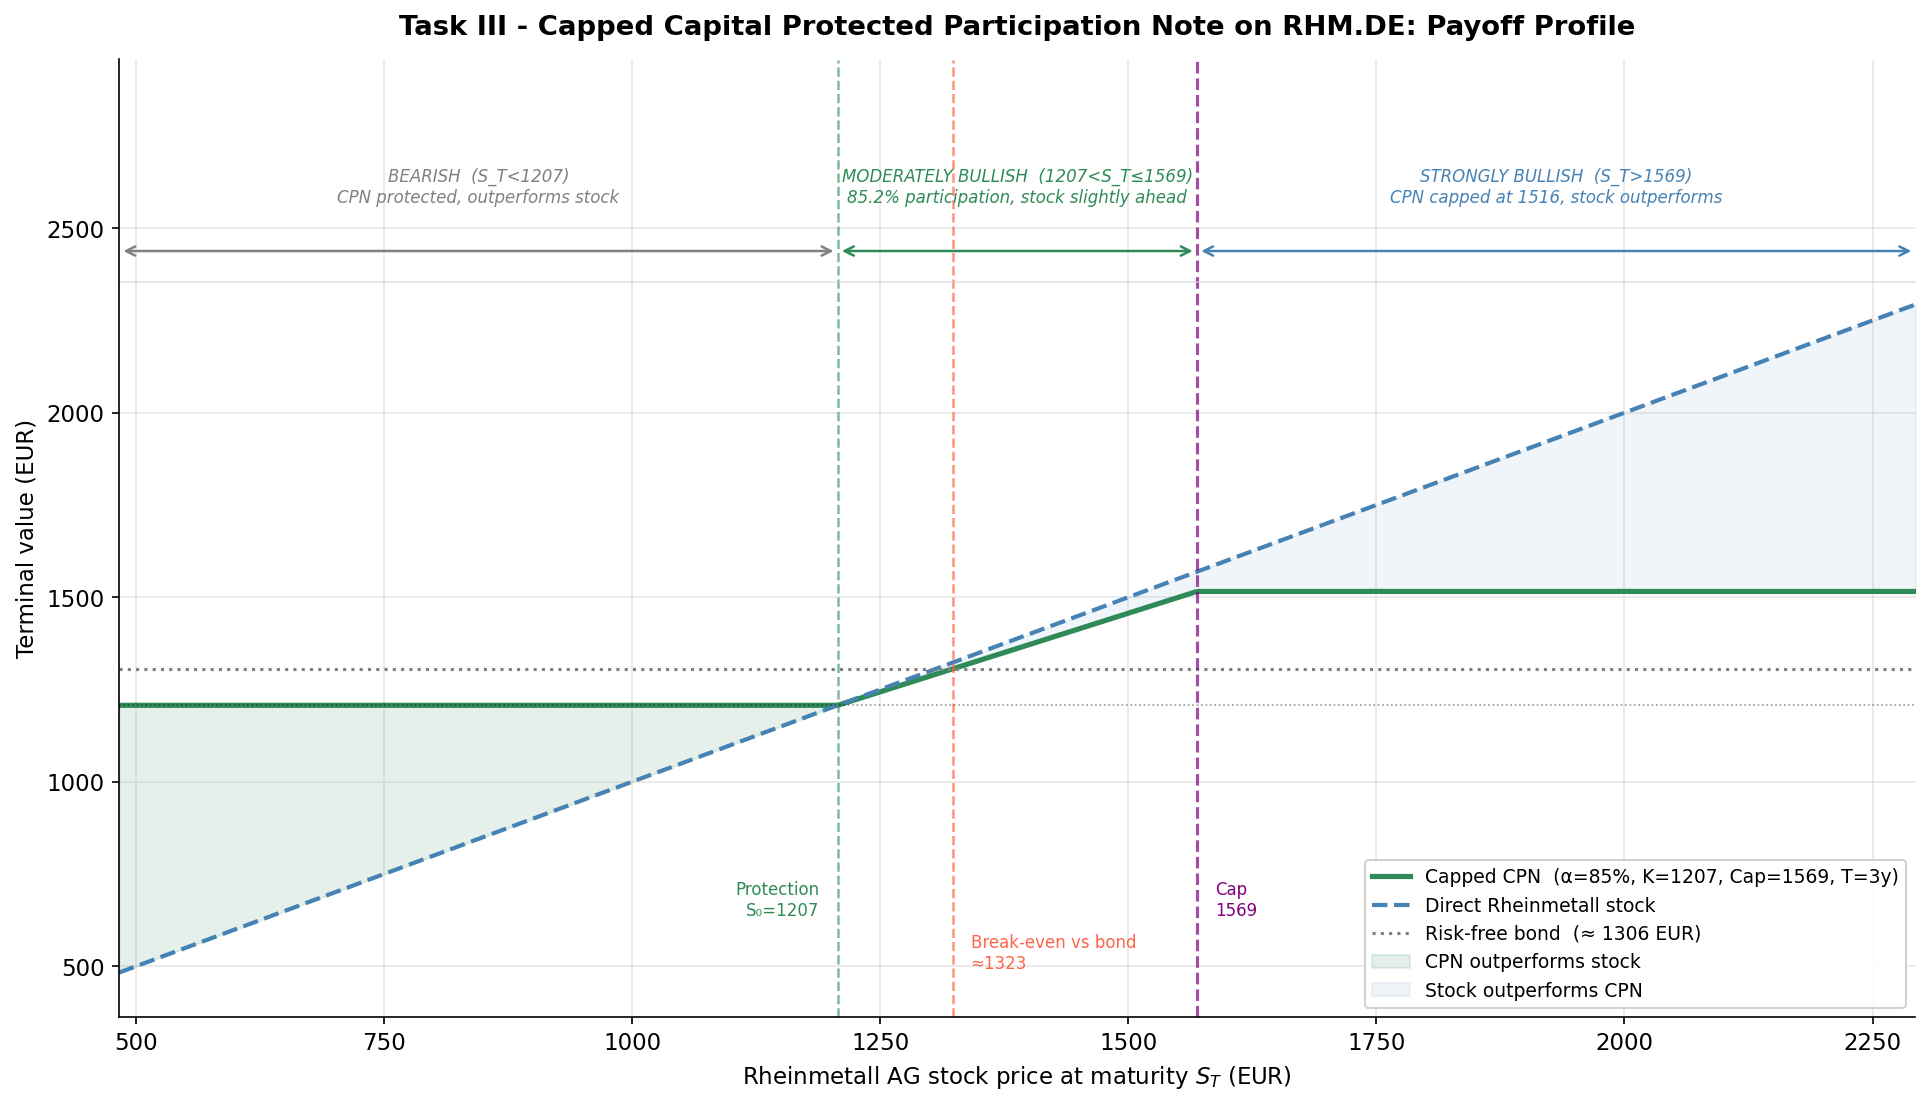

Max payoff at cap (S_T ≥ 1569): 1515.53 EUR  (+25.6% = 85% × 30%)

     S_T       CPN     Stock      Bond    CPN ret  Region
------------------------------------------------------------------------
   603.5   1207.00     603.5   1305.67     +0.00%  PROTECTED
   844.9   1207.00     844.9   1305.67     +0.00%  PROTECTED
  1086.3   1207.00    1086.3   1305.67     +0.00%  PROTECTED
  1207.0   1207.00    1207.0   1305.67     +0.00%  FLOOR (ATM)
  1322.8   1305.67    1322.8   1305.67     +8.17%  PARTICIPATING
  1327.7   1309.84    1327.7   1305.67     +8.52%  PARTICIPATING
  1569.1   1515.53    1569.1   1305.67    +25.56%  PARTICIPATING
  1810.5   1515.53    1810.5   1305.67    +25.56%  CAPPED MAX
  2051.9   1515.53    2051.9   1305.67    +25.56%  CAPPED MAX


In [59]:
# ranges are multiples of S0_CPN so the plot scales with the actual stock price
x_lo = S0_CPN * 0.40
x_hi = S0_CPN * 1.90

S_range     = np.linspace(x_lo, x_hi, 600)
bond_mature = S0_CPN * np.exp(R_CPN * T_CPN)

# Payoffs
payoff_cpn = np.where(
    S_range < K_CPN,
    S0_CPN,
    np.where(
        S_range <= K_CAP_CPN,
        S0_CPN + ALPHA_CPN * (S_range - K_CPN),
        S0_CPN + ALPHA_CPN * (K_CAP_CPN - K_CPN)
    )
)
payoff_stock = S_range
payoff_bond  = np.full_like(S_range, bond_mature)

max_payoff     = S0_CPN + ALPHA_CPN * (K_CAP_CPN - K_CPN)
breakeven_bond = K_CPN + (bond_mature - S0_CPN) / ALPHA_CPN

# header band at the top holds the regime arrows/labels
y_lo     = S0_CPN * 0.30
y_hi     = S0_CPN * 2.45
y_ann    = S0_CPN * 2.02   # regime arrow row
y_txt    = S0_CPN * 2.12   # regime label row (above the arrows)
y_lbl_hi = S0_CPN * 0.52   # upper row of lower labels
y_lbl_lo = S0_CPN * 0.40   # lower (staggered) row of lower labels

fig, ax = plt.subplots(figsize=(13, 7.5))

ax.plot(S_range, payoff_cpn,   color='seagreen',  lw=2.5,
        label=f'Capped CPN  (α={ALPHA_CPN:.0%}, K={K_CPN:.0f}, Cap={K_CAP_CPN:.0f}, T={T_CPN:.0f}y)')
ax.plot(S_range, payoff_stock, color='steelblue', lw=2, linestyle='--',
        label='Direct Rheinmetall stock')
ax.plot(S_range, payoff_bond,  color='gray',      lw=1.5, linestyle=':',
        label=f'Risk-free bond  (≈ {bond_mature:.0f} EUR)')

ax.axvline(K_CPN,          color='seagreen', lw=1.2, linestyle='--', alpha=0.6)
ax.axvline(K_CAP_CPN,      color='purple',   lw=1.5, linestyle='--', alpha=0.7)
ax.axvline(breakeven_bond, color='tomato',   lw=1.2, linestyle='--', alpha=0.7)
ax.axhline(S0_CPN,         color='black',    lw=0.8, linestyle=':',  alpha=0.4)

ax.text(K_CPN - S0_CPN*0.015,          y_lbl_hi, f'Protection\nS₀={K_CPN:.0f}',
        ha='right', va='bottom', color='seagreen', fontsize=8)
ax.text(breakeven_bond + S0_CPN*0.015, y_lbl_lo, f'Break-even vs bond\n≈{breakeven_bond:.0f}',
        ha='left', va='bottom', color='tomato', fontsize=8)
ax.text(K_CAP_CPN + S0_CPN*0.015,      y_lbl_hi, f'Cap\n{K_CAP_CPN:.0f}',
        ha='left', va='bottom', color='purple', fontsize=8)

ax.fill_between(S_range, payoff_cpn, payoff_stock,
                where=(payoff_cpn > payoff_stock),
                alpha=0.12, color='seagreen', label='CPN outperforms stock')
ax.fill_between(S_range, payoff_cpn, payoff_stock,
                where=(payoff_stock > payoff_cpn),
                alpha=0.08, color='steelblue', label='Stock outperforms CPN')

ax.annotate('', xy=(K_CPN,     y_ann), xytext=(x_lo,      y_ann),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
ax.annotate('', xy=(K_CAP_CPN, y_ann), xytext=(K_CPN,     y_ann),
            arrowprops=dict(arrowstyle='<->', color='seagreen', lw=1.2))
ax.annotate('', xy=(x_hi,      y_ann), xytext=(K_CAP_CPN,  y_ann),
            arrowprops=dict(arrowstyle='<->', color='steelblue', lw=1.2))

mid_bear = (x_lo + K_CPN) / 2
mid_part = (K_CPN + K_CAP_CPN) / 2
mid_bull = (K_CAP_CPN + x_hi) / 2

ax.text(mid_bear, y_txt,
        f'BEARISH  (S_T<{K_CPN:.0f})\nCPN protected, outperforms stock',
        ha='center', va='bottom', fontsize=8, color='gray', style='italic')
ax.text(mid_part, y_txt,
        f'MODERATELY BULLISH  ({K_CPN:.0f}<S_T≤{K_CAP_CPN:.0f})\n{ALPHA_CPN:.1%} participation, stock slightly ahead',
        ha='center', va='bottom', fontsize=8, color='seagreen', style='italic')
ax.text(mid_bull, y_txt,
        f'STRONGLY BULLISH  (S_T>{K_CAP_CPN:.0f})\nCPN capped at {max_payoff:.0f}, stock outperforms',
        ha='center', va='bottom', fontsize=8, color='steelblue', style='italic')

ax.axhline(S0_CPN * 1.95, color='lightgray', lw=0.8, alpha=0.7)

ax.set_xlabel('Rheinmetall AG stock price at maturity $S_T$ (EUR)')
ax.set_ylabel('Terminal value (EUR)')
ax.set_title('Task III - Capped Capital Protected Participation Note on RHM.DE: Payoff Profile',
             fontweight='bold', pad=12)
ax.set_xlim(x_lo, x_hi)
ax.set_ylim(y_lo, y_hi)
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('graphs/payoff_profile.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Max payoff at cap (S_T ≥ {K_CAP_CPN:.0f}): {max_payoff:.2f} EUR  '
      f'(+{(max_payoff/S0_CPN - 1)*100:.1f}% = {ALPHA_CPN:.0%} × {(K_CAP_CPN/S0_CPN - 1)*100:.0f}%)')
print()
print(f'{"S_T":>8}  {"CPN":>8}  {"Stock":>8}  {"Bond":>8}  {"CPN ret":>9}  Region')
print('-' * 72)
test_pts = sorted([S0_CPN*f for f in [0.50, 0.70, 0.90, 1.00, 1.10, 1.30, 1.50, 1.70]] + [breakeven_bond])
for s in test_pts:
    if s < K_CPN:
        cpn_val = S0_CPN
    elif s <= K_CAP_CPN:
        cpn_val = S0_CPN + ALPHA_CPN * (s - K_CPN)
    else:
        cpn_val = max_payoff
    ret    = cpn_val / S0_CPN - 1
    region = ('PROTECTED' if s < K_CPN else 'FLOOR (ATM)' if abs(s - K_CPN) < 1e-9
              else 'CAPPED MAX' if s > K_CAP_CPN else 'PARTICIPATING')
    print(f'{s:>8.1f}  {cpn_val:>8.2f}  {s:>8.1f}  {bond_mature:>8.2f}  {ret:>+9.2%}  {region}')


## Task IV. Market Size Estimation

The aggregate volume figures come from the 2023 German structured-products market volume report. The capital-protection segment share (3.80%, EUR 4,254 mn) is that report's product-category breakdown for 2023. The participation-note sub-share of about 55% is my own estimate. The report only gives the segment total, and at the major issuers most of the outstanding issues are participation-style (ZCB + call) rather than coupon-style. For the number of active issues I use roughly 130, based on the published issuer list: around six dominant issuers with about 15-25 active products each. That works out to an average issue size near EUR 33mn (EUR 4.26bn / 130 issues).

### Market Size Calculation

Start from the total German structured product market of EUR 112bn. The capital-protection segment is 3.8% of it (EUR 4.26bn), and participation notes are roughly 55% of the segment (EUR 2.34bn). Spread across about 130 active issues, that is an average issue of around EUR 33mn, which is a realistic size for a Rheinmetall-linked CPN on the Stuttgart exchange.

In [60]:
# market-size figures: 2023 German structured-products market report
total_german_market_bn  = 112.0   # total German structured product market (EUR bn)
cap_prot_share          = 0.038   # capital-protection products = 3.80% of the total (2023 report)
cap_prot_market_bn      = total_german_market_bn * cap_prot_share

participation_share     = 0.55    # participation notes ~55% of the capital-protection segment
participation_market_bn = cap_prot_market_bn * participation_share

# ~6 major issuers × ~20 active products each
n_active_issues   = 130
avg_issue_size_mn = cap_prot_market_bn * 1000 / n_active_issues

print(f'Capital-protection segment : EUR {cap_prot_market_bn:.2f} bn  ({cap_prot_share*100:.1f}% of EUR {total_german_market_bn:.0f} bn)')
print(f'Participation notes        : EUR {participation_market_bn:.2f} bn  ({participation_share*100:.0f}% of segment)')
print(f'Avg issue size             : EUR {avg_issue_size_mn:.0f} mn  ({n_active_issues} active issues)')


Capital-protection segment : EUR 4.26 bn  (3.8% of EUR 112 bn)
Participation notes        : EUR 2.34 bn  (55% of segment)
Avg issue size             : EUR 33 mn  (130 active issues)


### Market Size Results

| Parameter | Value |
|-----------|-------|
| Total German structured product market (2023 report) | EUR 112 bn |
| Capital-protection segment (2023 report) | EUR 4,254 mn (3.80%; 3.8% × 112 bn ≈ EUR 4.26 bn) |
| of which participation notes (α < 100%), own estimate | EUR ~2.3 bn (~55% of segment) |
| Estimated active issues | ~130 (~6 major issuers × ~20 products each) |
| Average issue size | EUR ~33 mn per product |

### Comparable Product Segments (2023 report)

| Segment | Volume (EUR mn) | Market share |
|---------|----------------:|-------------:|
| Structured bonds | 57,053 | 50.94% |
| Express certificates | 26,721 | 23.86% |
| Equity-linked bonds | 9,054 | 8.08% |
| Capital-protection certificates (this product's class) | 4,254 | 3.80% |
| Discount certificates | 3,927 | 3.51% |
| Index/participation certificates | 3,491 | 3.12% |
| Warrants & knock-out products | 2,542 | 2.27% |
| Outperformance/sprint & others (no cap. prot.) | 1,745 | 1.56% |
| Credit-linked notes | 1,636 | 1.46% |
| Bonus certificates | 1,200 | 1.07% |
| Constant-leverage certificates | 373 | 0.33% |
| TOTAL | ~112,000 | 100% |

Capital-protected products are a long-standing segment of the German retail market and trade daily on the Stuttgart exchange. Most of the demand comes from safety-oriented savers who still want some equity exposure. As deposit rates fall, capital-protected equity products look more attractive than leaving cash in a savings account, and under MiFID II suitability rules these notes count as low-risk, so they can be sold to conservative investors. The main issuers are DZ BANK, Commerzbank, LBBW, Goldman Sachs, HypoVereinsbank (UniCredit) and Société Générale.

A CPN on Rheinmetall AG would be around EUR 33 mn outstanding, which is in line with typical single-stock capital-protected issues on the Stuttgart exchange.


---
# Part 2. Valuation of Certificates

## Product Overview

The certificate valued in Part 2 is DU2076, a Bonus Cap Certificate issued by DZ BANK on Rheinmetall AG.

Sources:
- DZ BANK, DU2076 Bonus Cap 1.050 2027/06 on Rheinmetall AG, issuer product page (pricing, term sheet)
- Official Key Information Document (BIB/KID), DE000DU20767, PDF, regulatory PRIIPs document with payoff scenarios, costs and risk class
- Stuttgart Stock Exchange, DU2076, secondary market trading, intraday bid/ask

| Field | Value |
|-------|-------|
| WKN / ISIN | DU2076 / DE000DU20767 |
| Issuer | DZ BANK AG |
| Underlying | Rheinmetall AG (ISIN DE0007030009, Xetra) |
| Product type | Bonus Cap Certificate |
| Barrier (continuous) | €1,050, observed daily from 04 Sep 2025 to 18 Jun 2027 |
| Bonus / cap level | €2,000 |
| Participation ratio | 1 : 1 (subscription ratio = 1.00) |
| Issue date | 04 September 2025 |
| Last valuation day | 18 June 2027 |
| Payment date | 25 June 2027 |
| Barrier breached (as of 01 Jun 2026) | No; distance to barrier 13.01% (underlying at €1,207.00) |

### Payoff at Maturity

$$V_T = \begin{cases} 2{,}000 & \text{if } S_t > 1{,}050 \;\forall\, t \in [\text{04 Sep 2025},\, \text{18 Jun 2027}] \\ \min(S_T,\; 2{,}000) & \text{if barrier breached at any point} \end{cases}$$

As long as Rheinmetall never closes at or below €1,050 (≈ 13% below the 01 Jun 2026 level of €1,207.00) at any point in the product's life, the investor gets the full €2,000 bonus no matter where the stock ends up, which is a +61.8% return on the 01 Jun 2026 certificate price of €1,236.07. If the barrier is breached, the product turns into a capped linear position, min(S_T, 2,000). In effect the certificate gives up its dividend rights in exchange for conditional downside protection and the bonus.


## Pricing Engine

I split DU2076 into two building blocks and price them together on the same binomial tree:

$$V^{\text{cert}}(S_0) = \underbrace{V^{\text{DO-put}}(S_0;\; K_{\text{bonus}},\, B)}_{\text{down-and-out put}} \;+\; \underbrace{V^{\text{fwd-cap}}(S_0;\; K_{\text{cap}})}_{\min(S_T,\, K_{\text{cap}})}$$

The capped forward pays $\min(S_T, K_{\text{cap}})$ at maturity. The down-and-out put pays $\max(K_{\text{bonus}} - S_T,\, 0)$ but only on paths where the stock never touched the barrier. Black-Scholes is fine for a payoff that depends on the terminal price alone, but the barrier condition depends on the whole path: one touch of $B = 1{,}050$ EUR kills the bonus for good, even if the stock recovers later. The tree handles that by testing the barrier at every node and zeroing the knocked-out branches, so the price carries the real knock-out risk.


In [61]:
def bs_vanilla_put(S, K, r, q, sigma, T):
    # Black-Scholes European vanilla put price.
    if T <= 0:
        return float(max(K - S, 0.0))
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)


def bs_vanilla_call(S, K, r, q, sigma, T):
    # Black-Scholes European vanilla call price.
    if T <= 0:
        return float(max(S - K, 0.0))
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

### Binomial Tree Pricing Functions

Both path-dependent parts (the down-and-out put and the capped forward) are rolled back together in a single backward-induction pass over $N = 500$ steps. Each price is the average of an $N$-step and an $(N{+}1)$-step tree, which cancels the odd-even oscillation of the binomial tree.

In [62]:

def _bonus_cap_cert_price_one(S, K_cap, B_barrier, r, q, sigma, T, N, smooth_barrier=False):
    # Single binomial tree pass (N steps).
    dt  = T / N
    u   = np.exp(sigma * np.sqrt(dt))
    d   = 1.0 / u
    p   = (np.exp((r - q) * dt) - d) / (u - d)
    df  = np.exp(-r * dt)

    j   = np.arange(N + 1)
    S_T = S * u ** (2 * j - N)

    V_do = np.maximum(K_cap - S_T, 0.0)
    V_do[S_T <= B_barrier] = 0.0

    V_cf = np.minimum(S_T, K_cap)

    for i in range(N - 1, -1, -1):
        V_do = df * (p * V_do[1:i + 2] + (1 - p) * V_do[0:i + 1])
        V_cf = df * (p * V_cf[1:i + 2] + (1 - p) * V_cf[0:i + 1])
        S_i  = S * u ** (2 * np.arange(i + 1) - i)
        killed = S_i <= B_barrier
        # Derman-Kani-Ergener-Bardhan barrier correction: keeps the effective barrier at B.
        if smooth_barrier and killed.any():
            # B falls between node layers: pin the knock-out to 0 at B and
            # interpolate up to the first surviving node so the barrier stays put.
            k_hi = int(np.where(killed)[0].max())      # highest killed node
            V_do[killed] = 0.0
            if k_hi + 1 <= i:                          # a surviving node exists above
                S_lo, S_up = S_i[k_hi], S_i[k_hi + 1]
                V_do[k_hi] = V_do[k_hi + 1] * (S_lo - B_barrier) / (S_up - B_barrier)
        else:
            V_do[killed] = 0.0

    return float(max(V_do[0] + V_cf[0], 0.0))


def bonus_cap_cert_price(S, K_cap, B_barrier, r, q, sigma, T, N=500, smooth_barrier=False):
    # Cert = capped forward min(S_T, K_cap) + down-and-out put(K_cap, B).
    # Averages N and N+1 trees to kill odd-even oscillation; smooth_barrier turns
    # on the interpolation above for the Task VI Greek plots.
    if T <= 1e-8:
        return float(K_cap if S > B_barrier else min(S, K_cap))
    return 0.5 * (_bonus_cap_cert_price_one(S, K_cap, B_barrier, r, q, sigma, T, N,     smooth_barrier) +
                  _bonus_cap_cert_price_one(S, K_cap, B_barrier, r, q, sigma, T, N + 1, smooth_barrier))


### Pricing Methodology

Time is split into $N$ steps of length $\Delta t = T/N$, and at each node the stock moves up by $u$ or down by $d$:

$$u = e^{\sigma\sqrt{\Delta t}}, \qquad d = \frac{1}{u} = e^{-\sigma\sqrt{\Delta t}}$$

Since $u \cdot d = 1$ the tree recombines. With a continuous dividend yield $\theta$ the risk-neutral up-probability is

$$q = \frac{e^{(r-\theta)\,\Delta t} - d}{u - d}$$

From the terminal payoffs I roll back step by step, discounting the risk-neutral expectation each time and forcing the down-and-out put to zero at any node with $S \le B$. The root value is the certificate price.

## Task V. Daily Valuation

### Data Sources (DU2076)

| Parameter | Value | Source |
|-----------|-------|--------|
| Cap / bonus level | K = 2,000 EUR | DU2076 KID/BIB (PDF); DZ BANK product page |
| Knock-out barrier | B = 1,050 EUR | KID, as above |
| Maturity date | 18 June 2027 | KID, as above |
| Valuation window start | 4 Sep 2025 | First trading day of DU2076; listed on the Stuttgart exchange and onvista |
| Valuation window end | 1 Jun 2026 | Most recent available DU2076 closing price |
| Daily certificate closing prices | `data/cert_prices.csv` | onvista, DU2076 historical prices (`Schluss` column, semicolon-separated export, German decimal format, DD.MM.YYYY dates) |

### Daily Valuation Loop

The DU2076 market closes come from `cert_prices.csv` (an onvista.de export), and I line them up against the yfinance trading dates. That leaves 183 days from Sep 2025 to Jun 2026, comfortably above the assignment's 100-day minimum. On each day I work out the remaining maturity, pull the Svensson rate and the 30-day rolling vol, and price the certificate on the tree ($N=500$, averaged with $N{+}1$).

In [63]:
# DU2076 closing prices (onvista.de export)
cert_df = pd.read_csv(
    'data/cert_prices.csv', sep=';', encoding='utf-8-sig',
    decimal=',', thousands='.', dtype={'Datum': str}
)
cert_df['Datum'] = pd.to_datetime(cert_df['Datum'], format='%d.%m.%Y')
cert_df = cert_df.rename(columns={'Datum': 'Date', 'Schluss': 'Close'})
cert_df = cert_df.set_index('Date').sort_index()
cert_series = cert_df['Close'].dropna()

# align cert dates to the yfinance trading calendar
common_dates     = prices.index.intersection(cert_series.index)
stock_window = prices.loc[common_dates].copy()
cert_window      = cert_series.loc[common_dates].copy()

S_series  = stock_window.values.flatten()
dates     = stock_window.index
N         = len(S_series)
S_initial = float(S_series[0])

# DU2076 fixed parameters
K_cert = K_CERT    # from global params (DZ BANK KID)
B_cert = B_CERT    # from global params (DZ BANK KID)

print(f'Window : {dates[0].date()} to {dates[-1].date()}  ({N} days)')
print(f'S_initial = {S_initial:.2f},  K_cap = {K_cert:.2f},  B = {B_cert:.2f}')
print(f'Risk-free rate: daily ECB Svensson r(T_rem), maturity-matched per day')
print(f'Cert prices loaded: {len(cert_window)} days, {cert_window.iloc[0]:.2f} - {cert_window.iloc[-1]:.2f} EUR')

# model prices: 30-day rolling vol, daily maturity-matched Svensson r
model_prices = []
sigmas_used  = []
rates_used   = []

for i, (date, S) in enumerate(zip(dates, S_series)):
    T_rem     = max((MATURITY_DATE - date).days / 365, 1 / 365)
    sigma_est = float(np.clip(rolling_vol_30.asof(date), 0.10, 0.60))
    r_today   = get_risk_free_rate(date, T_rem)
    mp        = bonus_cap_cert_price(float(S), K_cert, B_cert, r_today, DIV_YIELD, sigma_est, T_rem)
    model_prices.append(mp)
    sigmas_used.append(sigma_est)
    rates_used.append(r_today)

model_prices = np.array(model_prices)
sigmas_used  = np.array(sigmas_used)
rates_used   = np.array(rates_used)

# market prices from onvista.de
market_prices = cert_window.values.astype(float)

print(f'30-day rolling vol: range {sigmas_used.min():.2%} - {sigmas_used.max():.2%}, mean {sigmas_used.mean():.2%}')
print(f'Mean Svensson r(T_rem): {rates_used.mean():.4%}  (range {rates_used.min():.4%} - {rates_used.max():.4%})')
print('Model and actual market prices computed.')


Window : 2025-09-04 to 2026-06-01  (183 days)
S_initial = 1707.93,  K_cap = 2000.00,  B = 1050.00
Risk-free rate: daily ECB Svensson r(T_rem), maturity-matched per day
Cert prices loaded: 183 days, 1635.75 - 1236.07 EUR
30-day rolling vol: range 26.33% - 58.59%, mean 44.38%
Mean Svensson r(T_rem): 2.1356%  (range 1.8739% - 2.5947%)
Model and actual market prices computed.


### Implied Volatility

There is no listed RHM option chain, so instead we back out the vol that makes the tree price equal the observed DU2076 market price on each day. We then compare that implied vol with the 30-day realized vol used for pricing. This is a way to check the claim below, that realized vol sits above what the market is actually pricing in.

Implied vol solved for 183 / 183 days (0 days had no bracket, issuer margin)
Mean implied vol               : 36.99%
Mean realized vol (30d rolling): 44.38%  (the Task V pricing input)
Mean gap (implied - realized)  : -7.40%


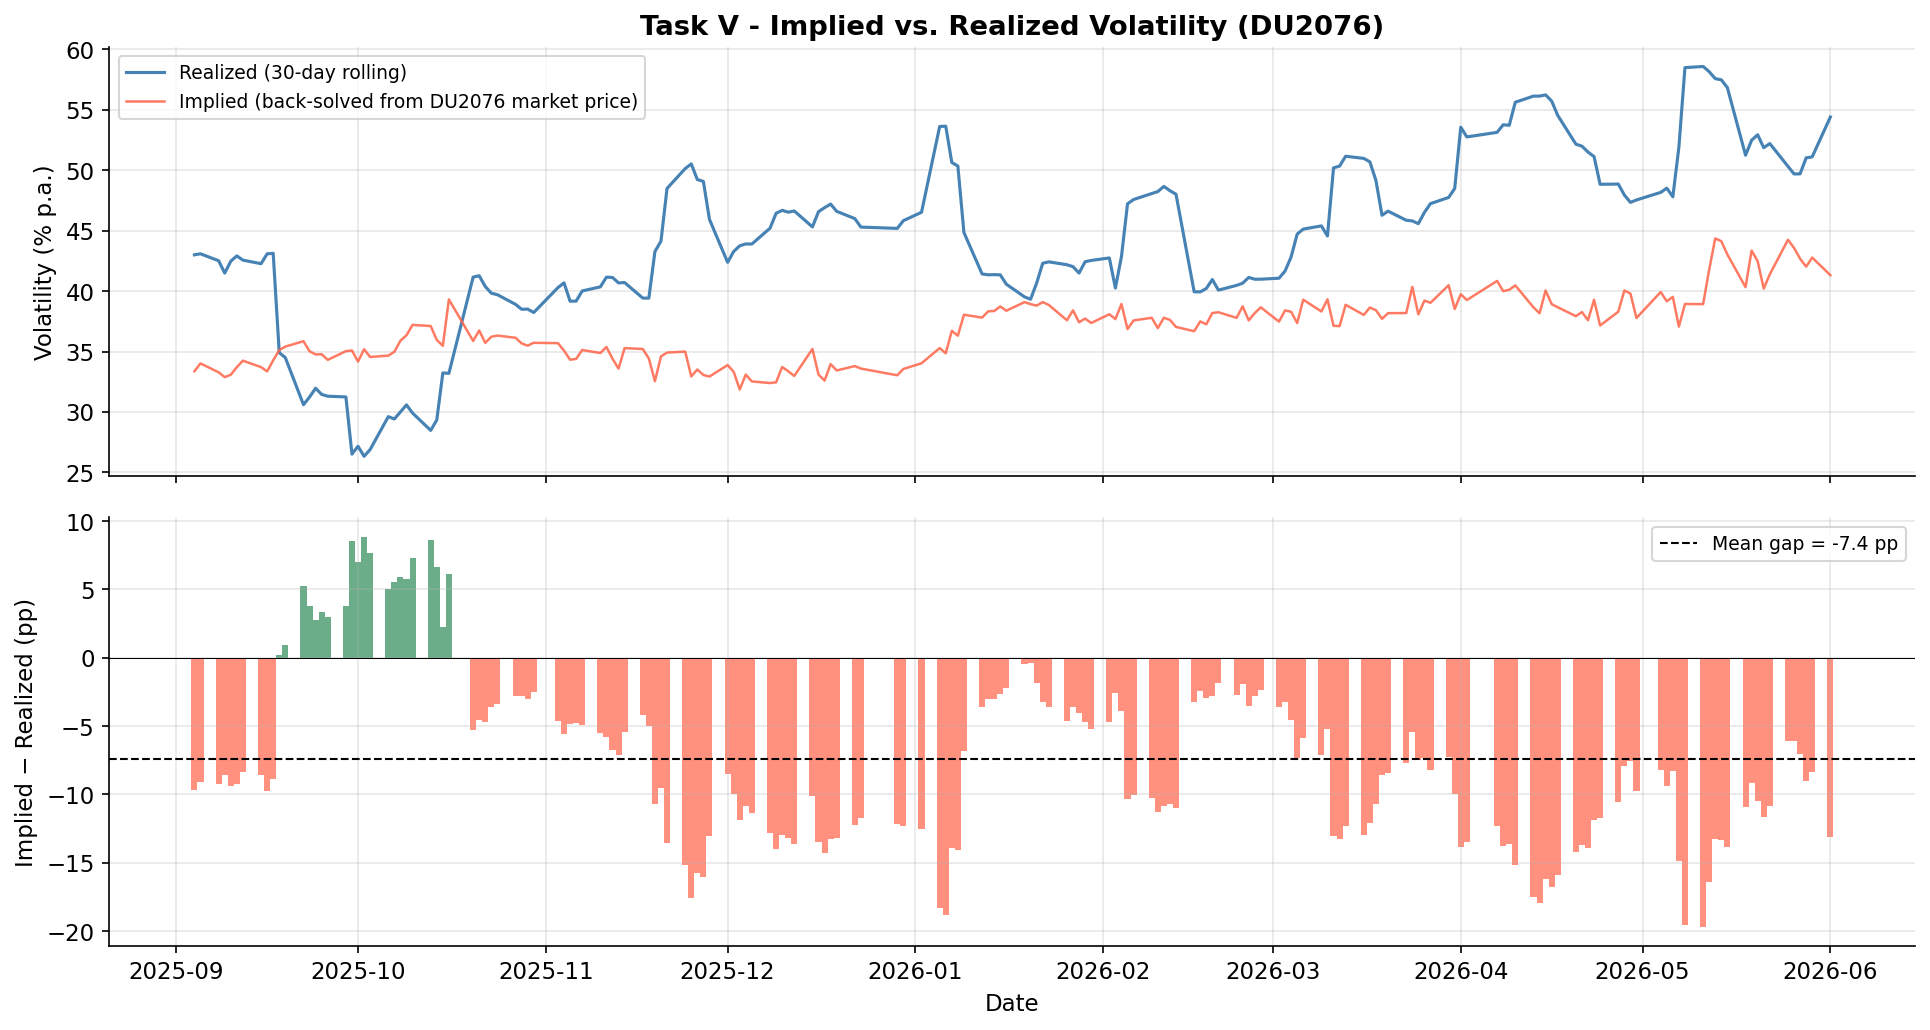

In [64]:
# implied vol back-solved per day. DU2076 has negative vega, so price is decreasing
# in sigma; days where the market price falls outside the achievable bracket
# (issuer margin) are left NaN. N=120 purely for solve speed, the official Task V
# prices use N=500 above.
from scipy.optimize import brentq

N_IMPLIED      = 120
SIG_LO, SIG_HI = 0.02, 2.00

def _implied_vol_for_day(S, mkt_price, r, q, T, K=K_cert, B=B_cert):
    f = lambda sig: bonus_cap_cert_price(S, K, B, r, q, sig, T, N=N_IMPLIED) - mkt_price
    lo_val, hi_val = f(SIG_LO), f(SIG_HI)
    if lo_val * hi_val > 0:
        return np.nan
    return brentq(f, SIG_LO, SIG_HI, xtol=1e-4, maxiter=60)

T_rem_all = np.array([max((MATURITY_DATE - d).days / 365, 1 / 365) for d in dates])
implied_vols = np.array([
    _implied_vol_for_day(float(S), float(mkt), r, DIV_YIELD, T)
    for S, mkt, r, T in zip(S_series, market_prices, rates_used, T_rem_all)
])

n_solved = int(np.sum(~np.isnan(implied_vols)))
vol_gap  = implied_vols - sigmas_used

print(f'Implied vol solved for {n_solved} / {len(implied_vols)} days '
      f'({len(implied_vols) - n_solved} days had no bracket, issuer margin)')
print(f'Mean implied vol               : {np.nanmean(implied_vols):.2%}')
print(f'Mean realized vol (30d rolling): {sigmas_used.mean():.2%}  (the Task V pricing input)')
print(f'Mean gap (implied - realized)  : {np.nanmean(vol_gap):+.2%}')

# implied vs realized chart (mirrors the lecture's DAX example)
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(dates, sigmas_used * 100, color='steelblue', lw=1.5, label='Realized (30-day rolling)')
axes[0].plot(dates, implied_vols * 100, color='tomato', lw=1.2, alpha=0.85,
             label='Implied (back-solved from DU2076 market price)')
axes[0].set_ylabel('Volatility (% p.a.)')
axes[0].set_title('Task V - Implied vs. Realized Volatility (DU2076)', fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].bar(dates, vol_gap * 100, color=['seagreen' if g >= 0 else 'tomato' for g in vol_gap],
            alpha=0.7, width=1)
axes[1].axhline(0, color='black', lw=0.5)
axes[1].axhline(np.nanmean(vol_gap) * 100, color='black', lw=1, linestyle='--',
                label=f'Mean gap = {np.nanmean(vol_gap)*100:+.1f} pp')
axes[1].set_ylabel('Implied − Realized (pp)')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('graphs/implied_vs_realized_vol.png', bbox_inches='tight')
plt.show()


### Pricing Error Metrics

Here we compute the pricing-accuracy statistics (ME, MAE, RMSE, MAPE, and error quantiles) for the rolling-vol model, whose mean σ is about 44.4% over the window. We then plot model against market price and the daily errors.

Task V pricing error metrics (DU2076)
  Mean Error (ME)          :    -94.25 EUR
  MAE                      :    110.89 EUR
  RMSE                     :    123.31 EUR
  MAPE                     :      7.11 %

  Error distribution quantiles:
  25th percentile          :   -153.59 EUR
  50th percentile (median) :    -95.02 EUR
  75th percentile          :    -56.44 EUR
  95th percentile          :     75.56 EUR


,RHM (EUR),Roll Vol,Implied Vol,Model (EUR),Mkt (EUR),Error (EUR)
Date,,,,,,
04 Sep 2025,1707.93,43.0%,33.4%,1481.75,1635.75,-154.00
05 Sep 2025,1727.24,43.1%,34.0%,1498.98,1648.28,-149.30
08 Sep 2025,1773.27,42.5%,33.3%,1528.16,1675.51,-147.35
09 Sep 2025,1761.39,41.5%,32.9%,1533.97,1671.59,-137.62
10 Sep 2025,1819.31,42.5%,33.1%,1551.32,1699.14,-147.82
05 Jan 2026,1734.66,53.6%,35.3%,1437.49,1682.59,-245.10
18 Sep 2025,1900.50,34.9%,35.1%,1704.93,1708.18,-3.25
15 May 2026,1120.00,56.8%,43.0%,1047.31,1112.65,-65.34
26 May 2026,1237.20,49.7%,43.6%,1207.75,1268.69,-60.94


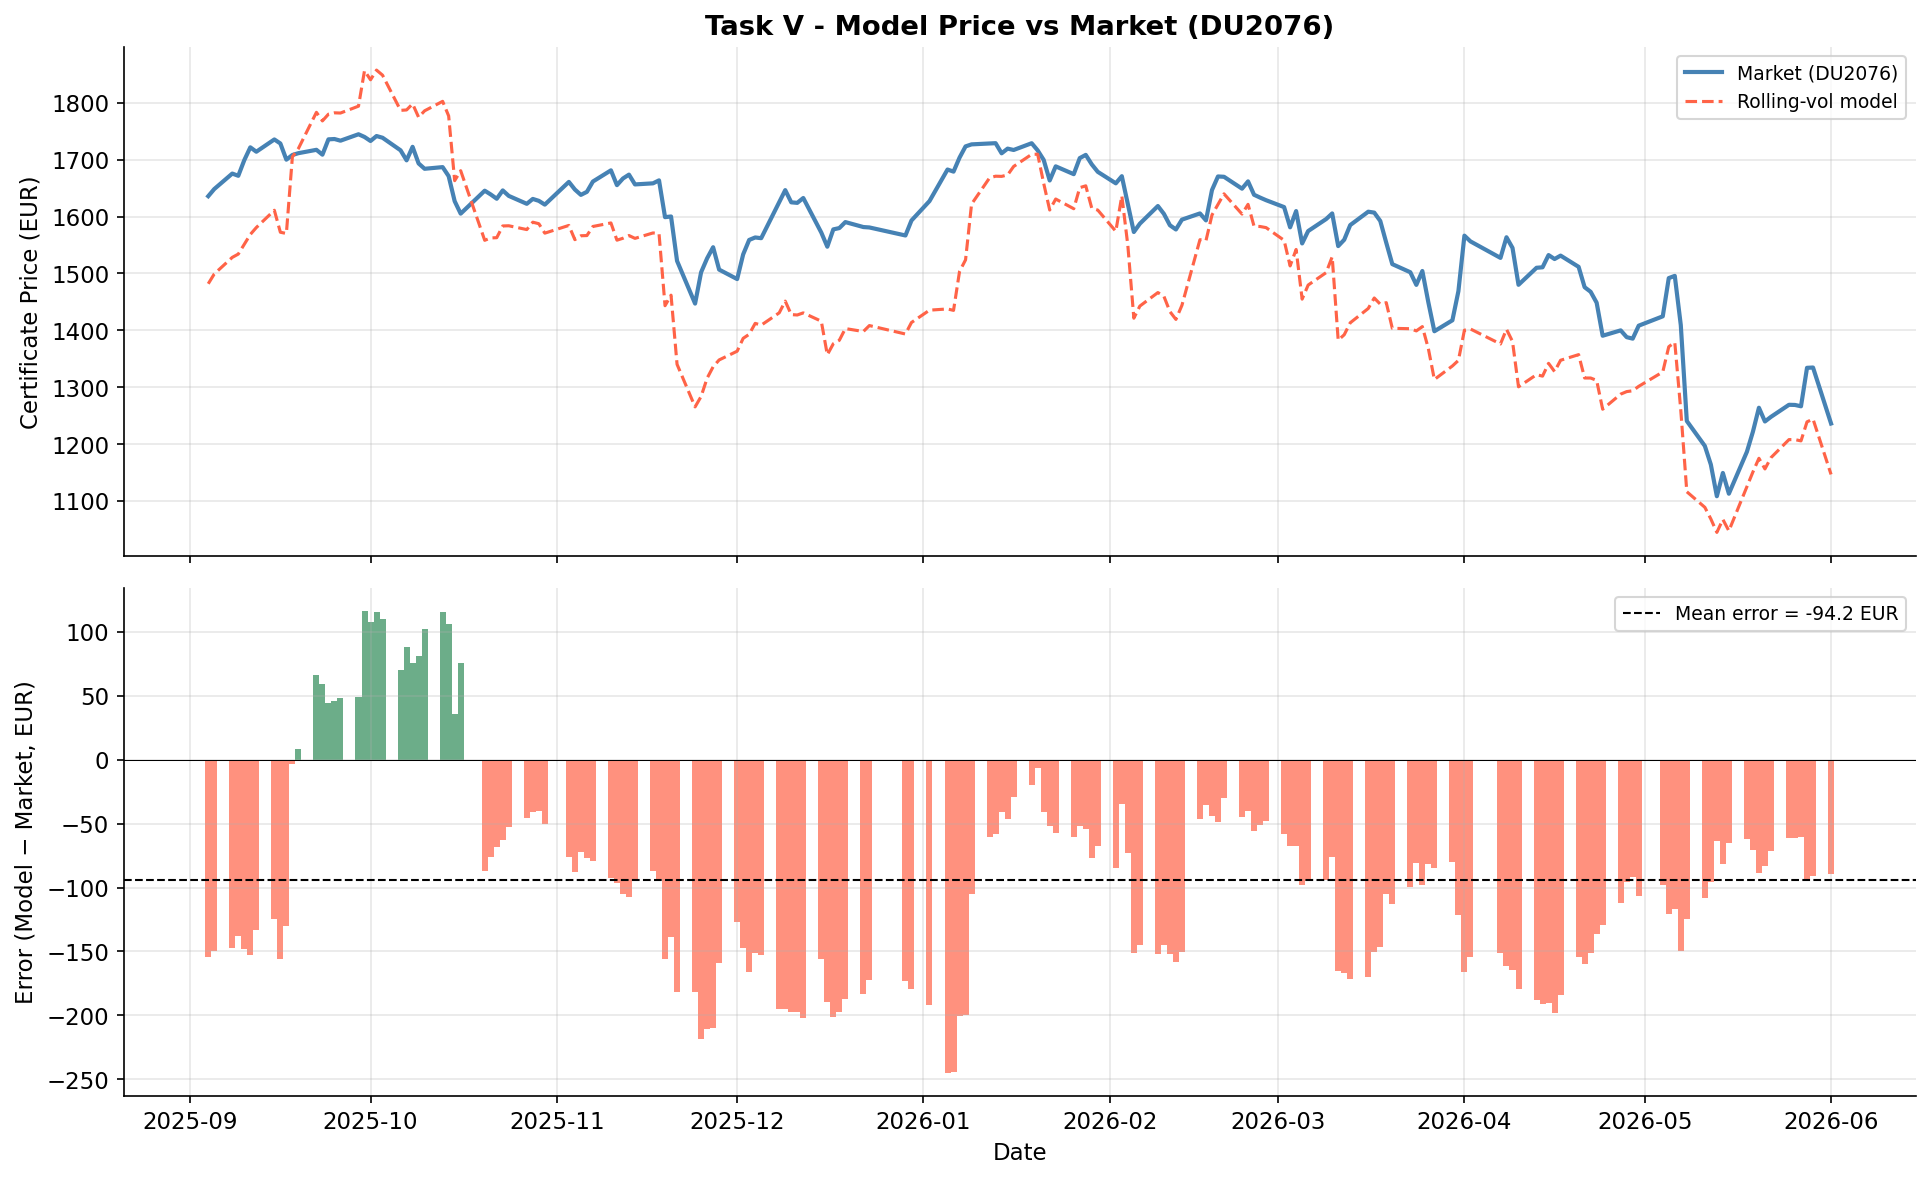

Saved: data/du2076_daily_comparison.csv


In [65]:
# error metrics
errors     = model_prices - market_prices
abs_errors = np.abs(errors)
rel_errors = np.abs(errors) / market_prices

ME   = np.mean(errors)
MAE  = np.mean(abs_errors)
RMSE = np.sqrt(np.mean(errors**2))
MAPE = float(np.mean(rel_errors) * 100)

# error distribution quantiles (required by the assignment)
q25, q50, q75, q95 = np.percentile(errors, [25, 50, 75, 95])

print('Task V pricing error metrics (DU2076)')
print(f'  Mean Error (ME)          : {ME:>9.2f} EUR')
print(f'  MAE                      : {MAE:>9.2f} EUR')
print(f'  RMSE                     : {RMSE:>9.2f} EUR')
print(f'  MAPE                     : {MAPE:>9.2f} %')
print()
print('  Error distribution quantiles:')
print(f'  25th percentile          : {q25:>9.2f} EUR')
print(f'  50th percentile (median) : {q50:>9.2f} EUR')
print(f'  75th percentile          : {q75:>9.2f} EUR')
print(f'  95th percentile          : {q95:>9.2f} EUR')

# selected-dates results table
idx_first   = list(range(5))
idx_last    = list(range(len(dates) - 5, len(dates)))
idx_worst   = int(np.argmax(abs_errors))
idx_best    = int(np.argmin(abs_errors))
idx_barrier = int(np.argmin(np.abs(S_series - B_cert)))

seen, selected_idx = set(), []
for idx in idx_first + [idx_worst, idx_best, idx_barrier] + idx_last:
    if idx not in seen:
        seen.add(idx); selected_idx.append(idx)

display(pd.DataFrame({
    'Date':         [dates[i].strftime('%d %b %Y') for i in selected_idx],
    'RHM (EUR)':    [round(S_series[i], 2)          for i in selected_idx],
    'Roll Vol':     [f'{sigmas_used[i]:.1%}'        for i in selected_idx],
    'Implied Vol':  [f'{implied_vols[i]:.1%}' if not np.isnan(implied_vols[i]) else 'n/a'
                                                     for i in selected_idx],
    'Model (EUR)':  [round(model_prices[i], 2)      for i in selected_idx],
    'Mkt (EUR)':    [round(market_prices[i], 2)     for i in selected_idx],
    'Error (EUR)':  [round(errors[i], 2)            for i in selected_idx],
}).set_index('Date'))

# price vs error chart
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(dates, market_prices, label='Market (DU2076)', color='steelblue', lw=2)
axes[0].plot(dates, model_prices,  label='Rolling-vol model', color='tomato',    lw=1.5, linestyle='--')
axes[0].set_ylabel('Certificate Price (EUR)')
axes[0].set_title('Task V - Model Price vs Market (DU2076)', fontweight='bold')
axes[0].legend(fontsize=9)

colors_bar = ['seagreen' if e >= 0 else 'tomato' for e in errors]
axes[1].bar(dates, errors, color=colors_bar, alpha=0.7, width=1)
axes[1].axhline(ME, color='black', lw=1, linestyle='--', label=f'Mean error = {ME:.1f} EUR')
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_ylabel('Error (Model − Market, EUR)')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('graphs/valuation_comparison.png', bbox_inches='tight')
plt.show()

# Persist the daily model-vs-market comparison for submission (regenerated each run)
pd.DataFrame({
    'Date': dates, 'RHM_Close': S_series, 'RollVol_pct': sigmas_used * 100,
    'Svensson_r_pct': rates_used * 100, 'Model_EUR': model_prices,
    'Market_EUR': market_prices, 'Error_EUR': errors,
}).set_index('Date').round(4).to_csv('data/du2076_daily_comparison.csv')
print('Saved: data/du2076_daily_comparison.csv')

### Results and Interpretation

The rolling-volatility model prices DU2076 too low across the window (mean error about −94 EUR, MAPE about 7.1%). There are two reasons. The first is that every onvista closing price already includes DZ BANK's manufacturing and distribution margin, and a risk-neutral tree has no way to capture that. The second is that the vol input is too high. The certificate has negative vega, and the mean implied vol of 36.99% is 7.40 pp below the mean realized (30-day) vol of 44.38%, so the model overstates the barrier risk and underprices.

The fit is closest on 18 Sep 2025 (error about −3 EUR), the day implied and realized vol almost line up (35.1% vs 34.9%). It is worst during the high-vol period in early January 2026, when realized vol (53.6%) ran furthest above implied (35.3%).

## Task VI. Sensitivity Analysis (Greeks)

The Greeks are computed numerically with central finite differences on `bonus_cap_cert_price`. The bumps have to be wide enough to clear the tree's own node spacing, otherwise the finite difference is mostly tree noise. Delta uses a 4% spot bump and Gamma a wider 8% bump, since the second difference is the most sensitive to node spacing. Vega uses a 2-percentage-point vol bump. To get clean curves the pricer fixes the knock-out exactly at the barrier instead of snapping it to the nearest node, and the sweep runs at N = 900 steps, so the Greeks come out smooth without any cosmetic filtering afterwards. Reference parameters: T = 1.79 y, σ = 44.7% (median 30-day rolling vol), and S_ref = 1,708 EUR.

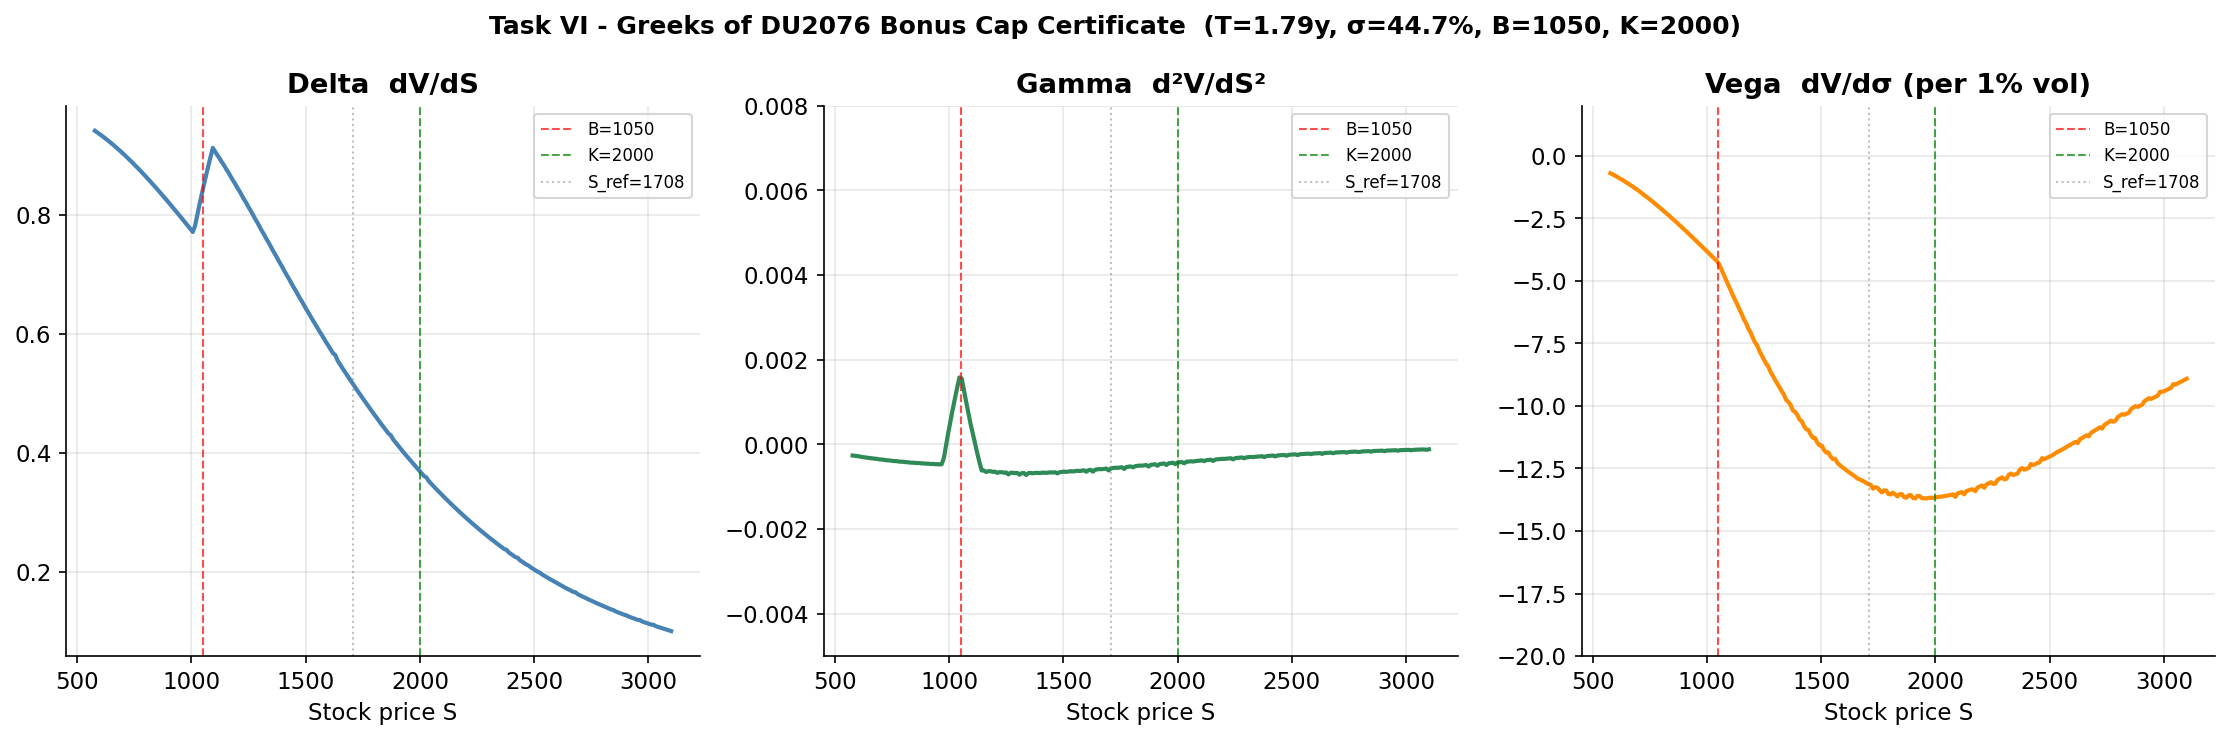

Greeks at reference stock price:
  price    = 1443.733199
  delta    = 0.515259
  gamma    = -0.000565
  vega     = -13.124096
  theta    = +0.5197  EUR per calendar day (365-day convention)
  rho      = -12.1452  EUR per +1pp interest rate


In [66]:
# numerical (central-difference) Greeks off the tree pricer.
# gamma needs a fatter bump than delta or the tree noise drowns the signal.
dS    = 0.04   # delta bump; must span >1 tree node (~2-3%) or the FD is pure noise
dSg   = 0.08   # gamma bump, a couple of nodes wide
dsig  = 0.02   # 2% vol bump

def compute_greeks(S, K, B_barrier, r, q, sigma, T, N=500, smooth_barrier=False):
    f     = lambda s, sig, t: bonus_cap_cert_price(s, K, B_barrier, r, q, sig, t,
                                                   N=N, smooth_barrier=smooth_barrier)
    price = f(S, sigma, T)
    delta = (f(S*(1+dS),  sigma, T) - f(S*(1-dS),  sigma, T)) / (2*dS*S)
    gamma = (f(S*(1+dSg), sigma, T) - 2*price + f(S*(1-dSg), sigma, T)) / (dSg*S)**2
    vega  = (f(S, sigma+dsig, T) - f(S, sigma-dsig, T)) / (2*dsig) / 100
    return {'price': price, 'delta': delta, 'gamma': gamma, 'vega': vega}

# Reference parameters: first DU2076 trading day (04 Sep 2025)
T_ref   = round(max((MATURITY_DATE - dates[0]).days / 365, 1/365), 2)
sig_ref = float(np.median(sigmas_used))
S_ref   = S_initial

# smooth_barrier=True pins the knock-out at B, so the curves come out clean
# without any post-hoc smoothing.
S_vals    = np.linspace(B_cert * 0.55, K_cert * 1.55, 260)
greeks_sweep = [compute_greeks(s, K_cert, B_cert, RISK_FREE, DIV_YIELD, sig_ref, T_ref,
                               N=900, smooth_barrier=True)
             for s in S_vals]

deltas = np.array([g['delta'] for g in greeks_sweep])
gammas = np.array([g['gamma'] for g in greeks_sweep])
vegas  = np.array([g['vega']  for g in greeks_sweep])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f'Task VI - Greeks of DU2076 Bonus Cap Certificate  '
    f'(T={T_ref:.2f}y, σ={sig_ref:.1%}, B={B_cert:.0f}, K={K_cert:.0f})',
    fontweight='bold', fontsize=12)

greek_panels = [
    (deltas, 'Delta  dV/dS',             'steelblue'),
    (gammas, 'Gamma  d²V/dS²', 'seagreen'),
    (vegas,  'Vega  dV/dσ (per 1% vol)', 'darkorange'),
]

for ax, (vals, name, color) in zip(axes, greek_panels):
    ax.plot(S_vals, vals, color=color, lw=2)
    ax.axvline(B_cert, color='red',   lw=1, linestyle='--', alpha=0.7, label=f'B={B_cert:.0f}')
    ax.axvline(K_cert, color='green', lw=1, linestyle='--', alpha=0.7, label=f'K={K_cert:.0f}')
    ax.axvline(S_ref,  color='gray',  lw=1, linestyle=':',  alpha=0.5, label=f'S_ref={S_ref:.0f}')
    ax.set_xlabel('Stock price S')
    ax.set_title(name, fontweight='bold')
    ax.legend(fontsize=8)
    if name.startswith('Gamma'):
        ax.set_ylim(-0.005, 0.008)
    elif name.startswith('Vega'):
        ax.set_ylim(-20, 2)

plt.tight_layout()
plt.savefig('graphs/greeks.png', bbox_inches='tight')
plt.show()

g_now = compute_greeks(S_ref, K_cert, B_cert, RISK_FREE, DIV_YIELD, sig_ref, T_ref,
                       N=900, smooth_barrier=True)
print('Greeks at reference stock price:')
for k, v in g_now.items():
    print(f'  {k:8s} = {v:.6f}')
# theta (365-day convention) and rho at the reference point
_f_ref    = lambda T=T_ref, r=RISK_FREE: bonus_cap_cert_price(S_ref, K_cert, B_cert, r, DIV_YIELD, sig_ref, T,
                                                              N=900, smooth_barrier=True)
h_T, h_r  = 5 / 365, 0.005
theta_day = -(_f_ref(T=T_ref + h_T) - _f_ref(T=T_ref - h_T)) / (2 * h_T) / 365
rho_1pp   =  (_f_ref(r=RISK_FREE + h_r) - _f_ref(r=RISK_FREE - h_r)) / (2 * h_r) / 100
print(f'  theta    = {theta_day:+.4f}  EUR per calendar day (365-day convention)')
print(f'  rho      = {rho_1pp:+.4f}  EUR per +1pp interest rate')

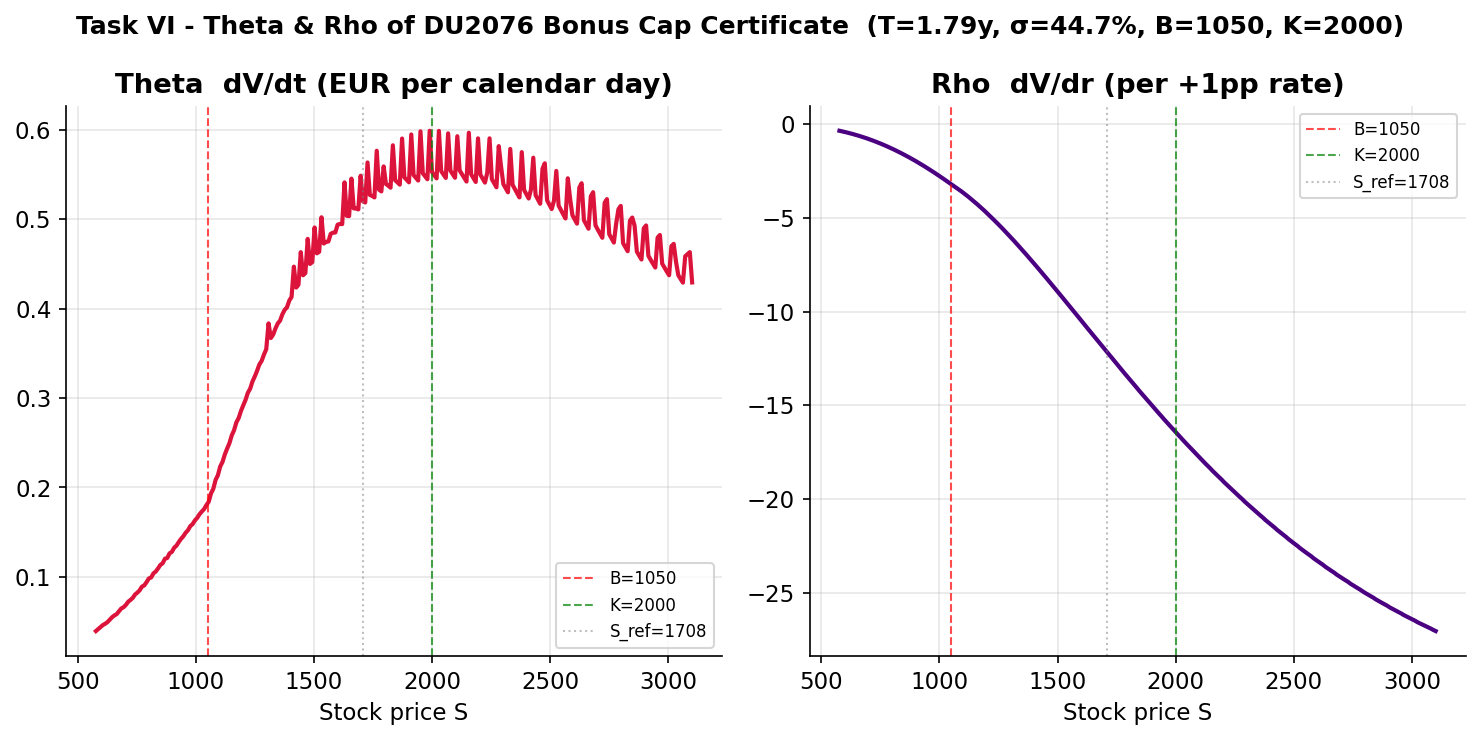

In [67]:
# theta and rho across spot (oral-presentation supplement)
def theta_rho(S, K, B_barrier, r, q, sigma, T, N=900, smooth_barrier=True):
    theta = -(bonus_cap_cert_price(S, K, B_barrier, r, q, sigma, T + h_T, N=N, smooth_barrier=smooth_barrier)
              - bonus_cap_cert_price(S, K, B_barrier, r, q, sigma, T - h_T, N=N, smooth_barrier=smooth_barrier)) / (2 * h_T) / 365
    rho   =  (bonus_cap_cert_price(S, K, B_barrier, r + h_r, q, sigma, T, N=N, smooth_barrier=smooth_barrier)
              - bonus_cap_cert_price(S, K, B_barrier, r - h_r, q, sigma, T, N=N, smooth_barrier=smooth_barrier)) / (2 * h_r) / 100
    return theta, rho

theta_rho_sweep = [theta_rho(s, K_cert, B_cert, RISK_FREE, DIV_YIELD, sig_ref, T_ref) for s in S_vals]
thetas = np.array([t for t, _ in theta_rho_sweep])
rhos   = np.array([r for _, r in theta_rho_sweep])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle(
    f'Task VI - Theta & Rho of DU2076 Bonus Cap Certificate  '
    f'(T={T_ref:.2f}y, σ={sig_ref:.1%}, B={B_cert:.0f}, K={K_cert:.0f})',
    fontweight='bold', fontsize=12)

greek_panels = [
    (thetas, 'Theta  dV/dt (EUR per calendar day)', 'crimson'),
    (rhos,   'Rho  dV/dr (per +1pp rate)',           'indigo'),
]

for ax, (vals, name, color) in zip(axes, greek_panels):
    ax.plot(S_vals, vals, color=color, lw=2)
    ax.axvline(B_cert, color='red',   lw=1, linestyle='--', alpha=0.7, label=f'B={B_cert:.0f}')
    ax.axvline(K_cert, color='green', lw=1, linestyle='--', alpha=0.7, label=f'K={K_cert:.0f}')
    ax.axvline(S_ref,  color='gray',  lw=1, linestyle=':',  alpha=0.5, label=f'S_ref={S_ref:.0f}')
    ax.set_xlabel('Stock price S')
    ax.set_title(name, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('graphs/theta_rho.png', bbox_inches='tight')
plt.show()


Gamma turns negative as S moves up toward the cap at K = 2,000. The certificate is effectively short an OTM call, so Delta falls as S rises, which is the opposite of a plain long position. Near the barrier Gamma spikes because the knock-out probability changes very fast there.

Vega is negative, for two reasons. The certificate is short a call at the cap, and that call is worth more when vol is high. On top of that, higher vol makes the barrier easier to hit. Both effects push the same way, so the holder is better off with low volatility. Theta is positive (+0.52 EUR/day on a 365-day convention), because each day that passes shortens the knock-out window and brings the fixed €2,000 redemption closer. Rho is negative (about −12.1 EUR per +1pp) since the value is mostly the discounted bonus, which behaves like a bond.

## Task VII. Replicating Portfolio

The replicating portfolio at each date $t$ holds $\Delta(t)$ shares of Rheinmetall and a bond position $B(t)$:

$$V(t) = \underbrace{\Delta(t)\cdot S(t)}_{\text{equity leg}} + \underbrace{B(t)}_{\text{bond leg}}, \qquad B(t) = V(t) - \Delta(t)\cdot S(t)$$

$\Delta(t)$ is read off the tree price with a central finite difference (±4% spot bump via `compute_greeks`), which matches the one-period branch ratio

$$\Delta = \frac{C_u - C_d}{S_u - S_d}$$

The equity fraction $\Delta(t)\cdot S(t) / V(t)$ is the share of the certificate's value carried by the stock leg. It can go above 100% near the barrier, where Delta rises toward 1.0 while the certificate value falls, so the bond leg turns negative. Both $\Delta(t)$ and $V(t)$ use the same 30-day rolling vol as the Task V loop, together with the constant Svensson benchmark rate.

In [68]:
# daily replicating portfolio: delta shares + bond
rep_deltas  = []
rep_bonds   = []
equity_frac = []

for i, (date, S) in enumerate(zip(dates, S_series)):
    T_rem     = max((MATURITY_DATE - date).days / 365, 1 / 365)
    sigma_est = float(np.clip(sigmas_used[i], 0.10, 0.60))

    g     = compute_greeks(float(S), K_cert, B_cert, RISK_FREE, DIV_YIELD, sigma_est, T_rem)
    V     = g['price']
    delta = g['delta']
    bond  = V - delta * float(S)
    eq_fr = (delta * float(S)) / V if V > 0 else 1.0

    rep_deltas.append(delta)
    rep_bonds.append(bond)
    equity_frac.append(eq_fr)

rep_deltas  = np.array(rep_deltas)
rep_bonds   = np.array(rep_bonds)
equity_frac = np.array(equity_frac)


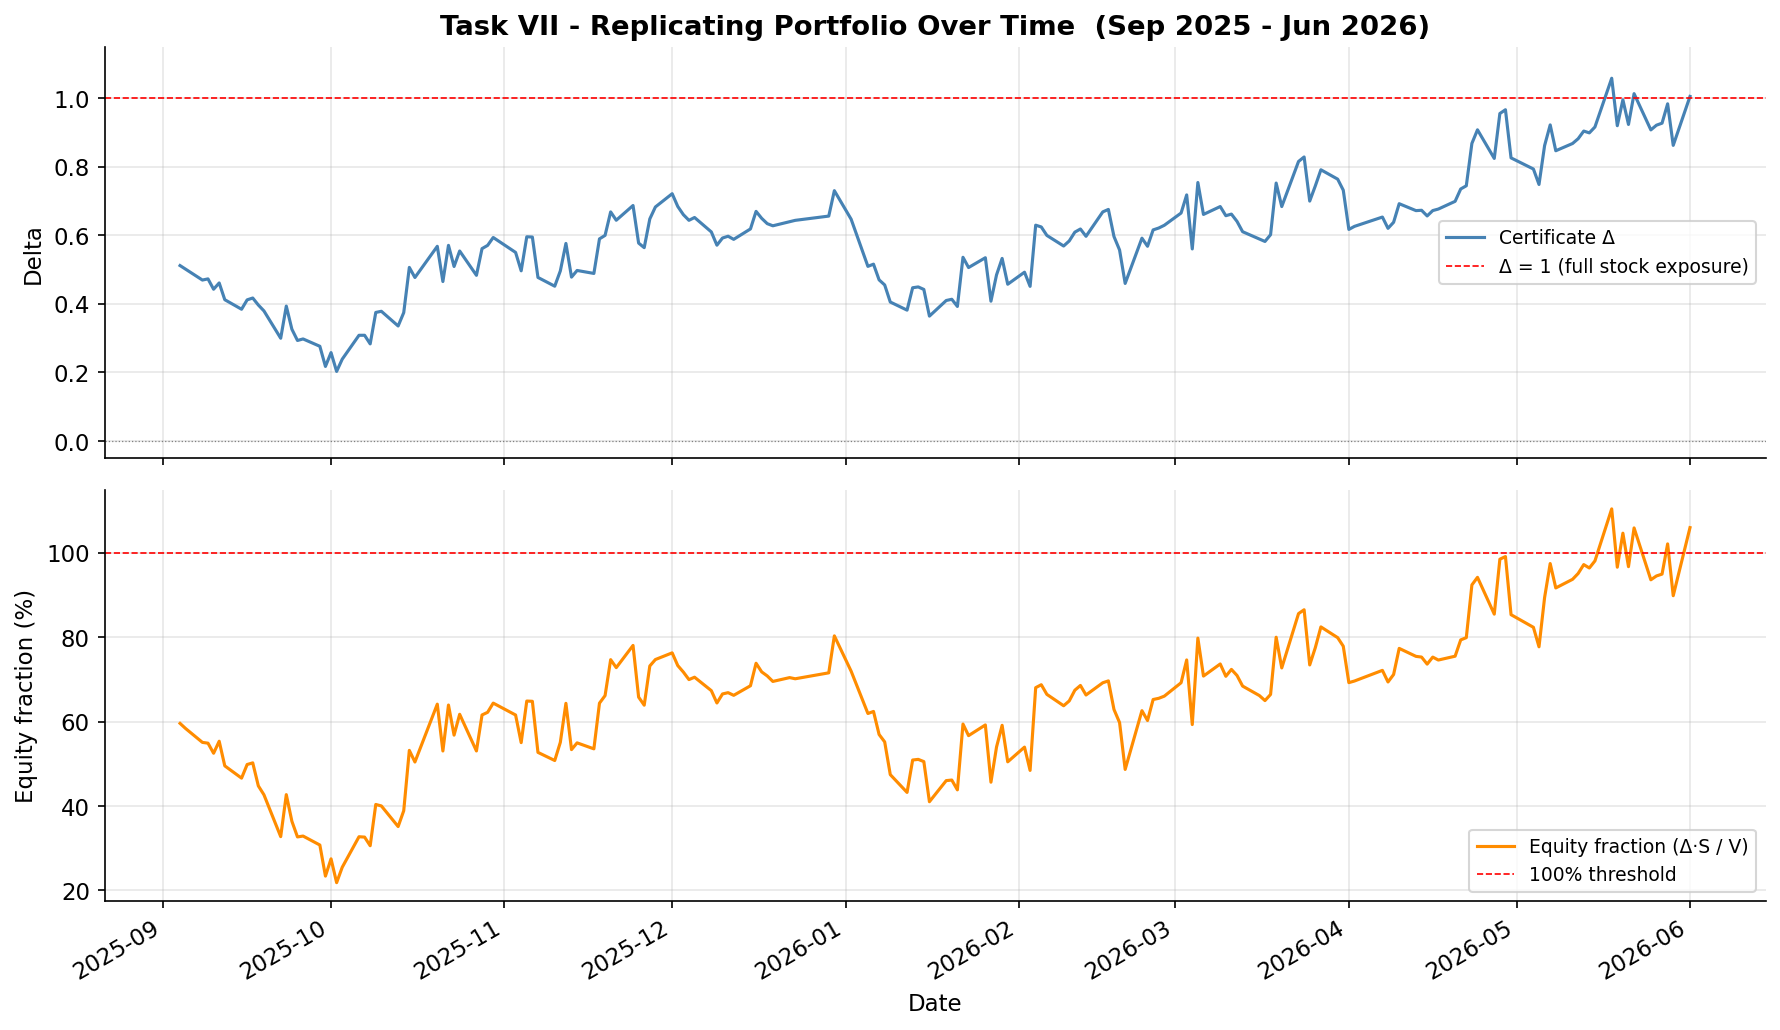

Delta range:            [0.203, 1.059]
Equity fraction range:  [21.8%, 110.5%]
Days eq. frac > 50%:    152 of 183


In [69]:
# delta and equity fraction over the observation window
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# delta
ax1.plot(dates, rep_deltas, color='steelblue', lw=1.5, label='Certificate Δ')
ax1.axhline(1.0, color='red',  lw=0.8, ls='--', label='Δ = 1 (full stock exposure)')
ax1.axhline(0.0, color='grey', lw=0.6, ls=':')
ax1.set_ylabel('Delta')
ax1.set_title('Task VII - Replicating Portfolio Over Time  (Sep 2025 - Jun 2026)',
              fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_ylim(-0.05, 1.15)

# equity fraction
eq_arr = np.array(equity_frac)
ax2.plot(dates, eq_arr * 100, color='darkorange', lw=1.5,
         label='Equity fraction (Δ·S / V)')
ax2.axhline(100, color='red', lw=0.8, ls='--', label='100% threshold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Equity fraction (%)')
ax2.legend(fontsize=9)

fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('graphs/replicating_portfolio_time.png', bbox_inches='tight')
plt.show()

print(f'Delta range:            [{rep_deltas.min():.3f}, {rep_deltas.max():.3f}]')
eq_vals = np.array(equity_frac)
print(f'Equity fraction range:  [{eq_vals.min():.1%}, {eq_vals.max():.1%}]')
print(f'Days eq. frac > 50%:    {(eq_vals > 0.5).sum()} of {len(eq_vals)}')


### Delta and Equity Fraction Over Time

Delta started near 0.60 (S ≈ 1,708) and dropped to its window low of about 0.20 as the stock rallied toward €1,900-1,950 in autumn 2025. Close to the cap and with vol easing, the certificate started to look more like its fixed bonus leg. When the stock fell back through 2026, Delta climbed steadily and reached about 0.9-1.1 near the barrier in May 2026. By then the certificate was basically a 1:1 long in Rheinmetall, sometimes slightly leveraged, with almost no protection left.

The equity fraction (Δ·S / V) started around 70%, fell to about 22% during the rally, stayed above 50% on 152 of the 183 days, and peaked near 110% in May 2026, where the bond leg went negative. That is the structural difference from a capital-protected note, where Delta goes to 0 as S falls. A bonus certificate carries its biggest stock exposure at the worst possible time, and once the barrier is breached the protection is gone for good.

### Equity Fraction vs Stock Price (Static Snapshot)

The plot sweeps the stock price from 0.5·B to 1.6·K at a fixed T_rem ≈ 1.79 y (the first DU2076 trading day, 04 Sep 2025; DZ BANK KID) and the median 30-day rolling vol, which isolates the stock-price effect with time held fixed. Above the barrier the fraction peaks near B = 1,050 (Delta toward 1, bond leg negative) and then falls toward zero at high prices, where the certificate behaves like its bond leg. Below the barrier the certificate has knocked out into a capped forward, $S e^{-qT} - \text{Call}(K{=}2{,}000)$. The fraction drops to about 81% just under B, since the short cap call still absorbs roughly a quarter of the exposure, and then climbs back toward about 98% as S falls further, meaning almost full downside with no protection left.

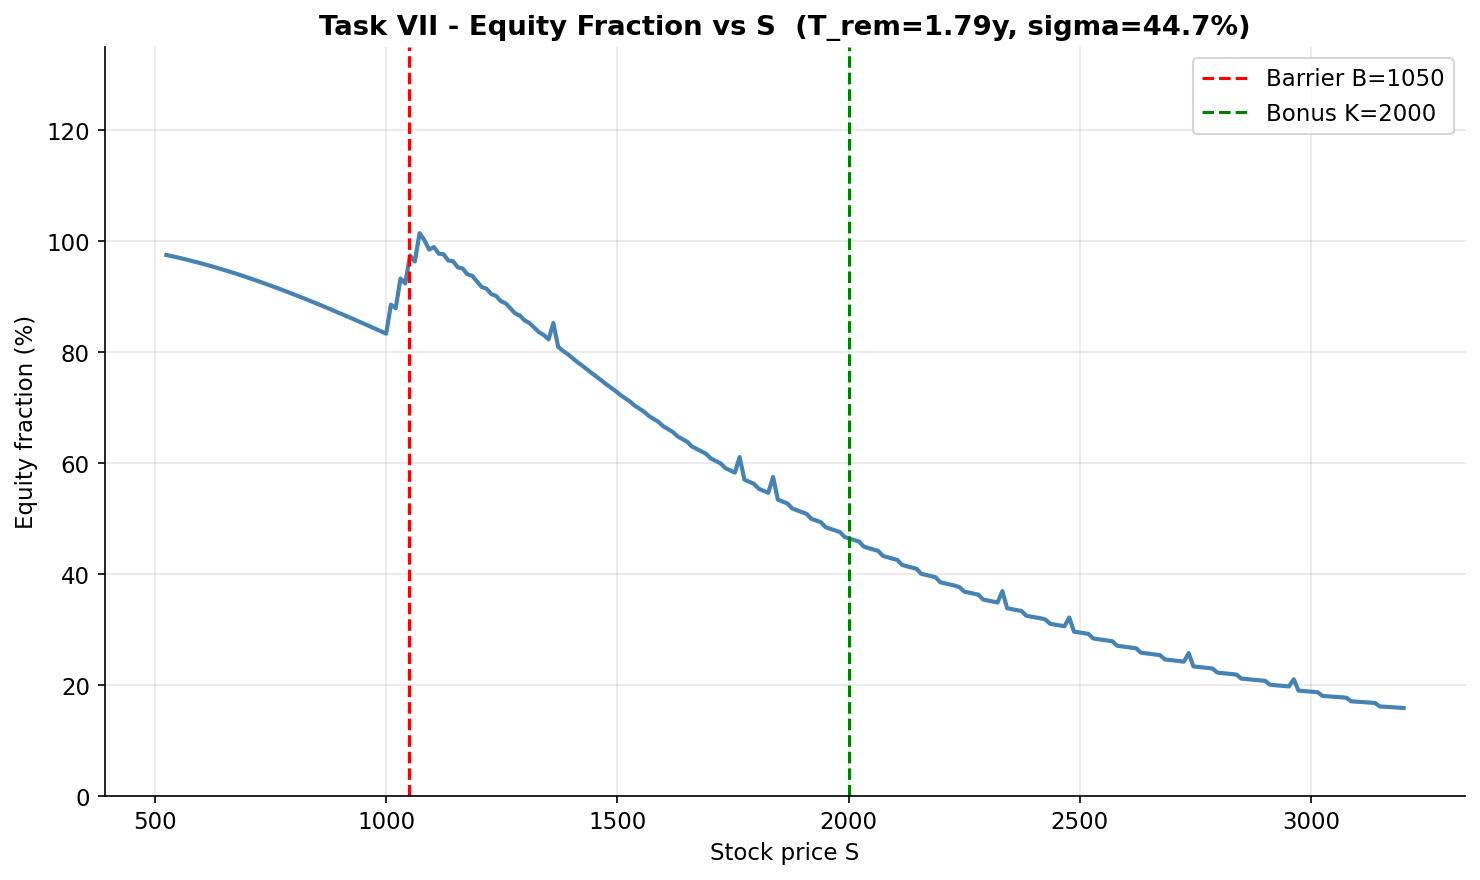

In [70]:
# equity fraction vs S (static snapshot at T_rem = T_ref)
# T_snap reuses T_ref, the remaining maturity on the first DU2076 trading day (04 Sep 2025)
T_snap   = T_ref
sig_snap = float(np.median(sigmas_used))

# S grid brackets the barrier (1,050) and the cap (2,000). The tree already
# prices the knocked-out region below B, so one code path covers everything;
# the jump at S = B is the real knock-out discontinuity.
S_cross  = np.linspace(B_cert * 0.50, K_cert * 1.60, 260)
eq_cross = []

for s in S_cross:
    g = compute_greeks(s, K_cert, B_cert, RISK_FREE, DIV_YIELD, sig_snap, T_snap, N=900)
    V = g['price']
    d = g['delta']
    eq_cross.append((d * s / V) if V > 0 else 1.0)

eq_cross = np.array(eq_cross)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(S_cross, eq_cross * 100, color='steelblue', lw=2)
ax.axvline(B_cert, color='red',   lw=1.5, linestyle='--', label=f'Barrier B={B_cert:.0f}')
ax.axvline(K_cert, color='green', lw=1.5, linestyle='--', label=f'Bonus K={K_cert:.0f}')
ax.set_xlabel('Stock price S')
ax.set_ylabel('Equity fraction (%)')
ax.set_title(f'Task VII - Equity Fraction vs S  (T_rem={T_snap}y, sigma={sig_snap:.1%})',
             fontweight='bold')
ax.legend()
ax.set_ylim(0, 135)

plt.tight_layout()
plt.savefig('graphs/equity_fraction_vs_S.png', bbox_inches='tight')
plt.show()


---
# Part 3. Portfolio Insurance Strategy

Initial capital EUR 10,000, horizon T* = 1 year, underlying Rheinmetall AG (RHM.DE).

### Monte Carlo Parameter Sources

| Parameter | Value | Source |
|-----------|-------|--------|
| Initial capital W₀ | EUR 10,000 | Specified in assignment |
| Investment horizon T* | 1 year | Specified in assignment |
| VaR constraint (Task XI) | 15% | Specified in assignment |
| Underlying S₀ | EUR 1,207.00 | Latest RHM.DE adjusted close (Yahoo Finance) |
| Simulation drift | r − q − ½σ² = −8.27% p.a. | Risk-neutral, per the standard risk-neutral recipe; the large negative value is the −½σ² drag at σ ≈ 45.6% (see Modelling Conventions) |
| Volatility σ | 45.57% p.a. | 252-day trailing historical std dev of daily log-returns up to 01 Jun 2026, annualised; used as both the simulation and the option-pricing vol per the brief |
| Risk-free rate r | 3.07% | ECB Svensson, AAA euro-area curve (01 Jun 2026), 10y benchmark; the same `RISK_FREE` used for the Task VI to VII Greeks/replication |
| Dividend yield q | 0.95% | Rheinmetall FY2025 dividend yield (`DIV_YIELD`, see Global Parameters) |
| Historical drift μ (reference only) | 54.05% p.a. | Mean daily log-return annualised (Jan 2023 to Jun 2026); reported for context, not used as the drift |
| Paths / steps | 50,000 / 252 | Standard MC precision; seed = 2026 for reproducibility |

### Monte Carlo Path Generation

The engine draws 50,000 one-year price paths at daily frequency (252 steps) under the risk-neutral measure, with drift r − q − ½σ² from the standard risk-neutral recipe and σ set to the 252-day trailing historical vol. I fix the seed at 2026 and reuse the same paths across all four tasks (VIII to XI), so any gap between strategies comes down to the strategy itself and not to Monte Carlo noise.

In [71]:
# Monte Carlo parameters
W0       = 10_000
T_star   = 1.0
N_STEPS  = 252
N_PATHS  = 50_000
S0_mc    = float(prices.iloc[-1])
mu_hist  = float(log_returns.mean() * 252)   # reference only, not the simulation drift
sigma_mc = float(log_returns.loc[:'2026-06-01'].iloc[-252:].std() * np.sqrt(252))  # 252-day trailing historical vol to 01 Jun 2026

# risk-neutral drift per the course's MC recipe: d ln S = (r - q - sigma^2/2) dt + sigma sqrt(dt) z
mu_rn = RISK_FREE - DIV_YIELD - 0.5 * sigma_mc**2

print('Monte Carlo Setup:')
print(f'  S0            = EUR {S0_mc:.2f}')
print(f'  r  (drift)    = {RISK_FREE:.2%}   (risk-neutral rate)')
print(f'  q  (dividend) = {DIV_YIELD:.2%}')
print(f'  sigma         = {sigma_mc:.2%}   (252-day trailing historical)')
print(f'  mu hist       = {mu_hist:.2%}   (reference only, not the simulation drift)')
print(f'  Paths         = {N_PATHS:,}')

# simulate the risk-neutral log-price paths (exact GBM discretisation)
dt_mc = T_star / N_STEPS
np.random.seed(2026)

Z          = np.random.standard_normal((N_PATHS, N_STEPS))
increments = mu_rn * dt_mc + sigma_mc * np.sqrt(dt_mc) * Z
log_paths  = np.cumsum(increments, axis=1)
S_paths    = S0_mc * np.exp(np.hstack([np.zeros((N_PATHS, 1)), log_paths]))
S_terminal = S_paths[:, -1]

print(f'Simulation complete.')
print(f'Terminal price range: {S_terminal.min():.1f} - {S_terminal.max():.1f}')

Monte Carlo Setup:
  S0            = EUR 1207.00
  r  (drift)    = 3.07%   (risk-neutral rate)
  q  (dividend) = 0.95%
  sigma         = 45.57%   (252-day trailing historical)
  mu hist       = 54.05%   (reference only, not the simulation drift)
  Paths         = 50,000
Simulation complete.
Terminal price range: 136.3 - 7665.6


### Modelling Conventions for Tasks VIII to XI

The paths evolve the log-price under the risk-neutral measure, Δ ln S = (r − q − ½σ²)·Δt + σ·√Δt·Z, using the same `RISK_FREE` and `DIV_YIELD` that price the puts, so the simulation and the pricing stay on the same measure. Rheinmetall's realised historical mean of 54.05% p.a. reflects the 2023-2026 re-rating of the stock and is kept as `mu_hist` for reference only, not used as a drift.

At σ ≈ 45.6% the −½σ² term is about −10.4% p.a., which is bigger than r − q ≈ 2.1%, so the risk-neutral log-drift works out to −8.27% p.a. This is not me predicting the stock will fall. In simple (arithmetic) terms the mean return is +2.16%, close to e^{r−q} − 1 ≈ 2.14%, which is what a risk-neutral asset should give. The reason the put overlay in Tasks IX to XI is worth anything is the large 56.38% downside VaR, not a negative average.

All Part 3 performance and risk figures use simple wealth return, `wealth_T / wealth_0 − 1`, so the Task XI 15% ceiling caps relative wealth loss directly.

## Task VIII. Performance Analysis (No Risk Management)

`performance_stats` reports the five headline measures (mean, standard deviation, skewness, 95% VaR, and 95% CVaR), which fits the assignment's guidance of 4 to 5 measures. We run it first on the fully unhedged stock position (all of W₀ = €10,000 in Rheinmetall), which is the baseline for Tasks IX to XI.

--- Task VIII - Unhedged (pure stock) ---
  Mean return       :    2.16%
  Std deviation     :   49.34%
  Skewness          :    1.596
  95% VaR (loss)    :   56.38%
  95% CVaR (loss)   :   63.60%

MC precision: 50,000 paths; standard error of the mean return = 0.221%


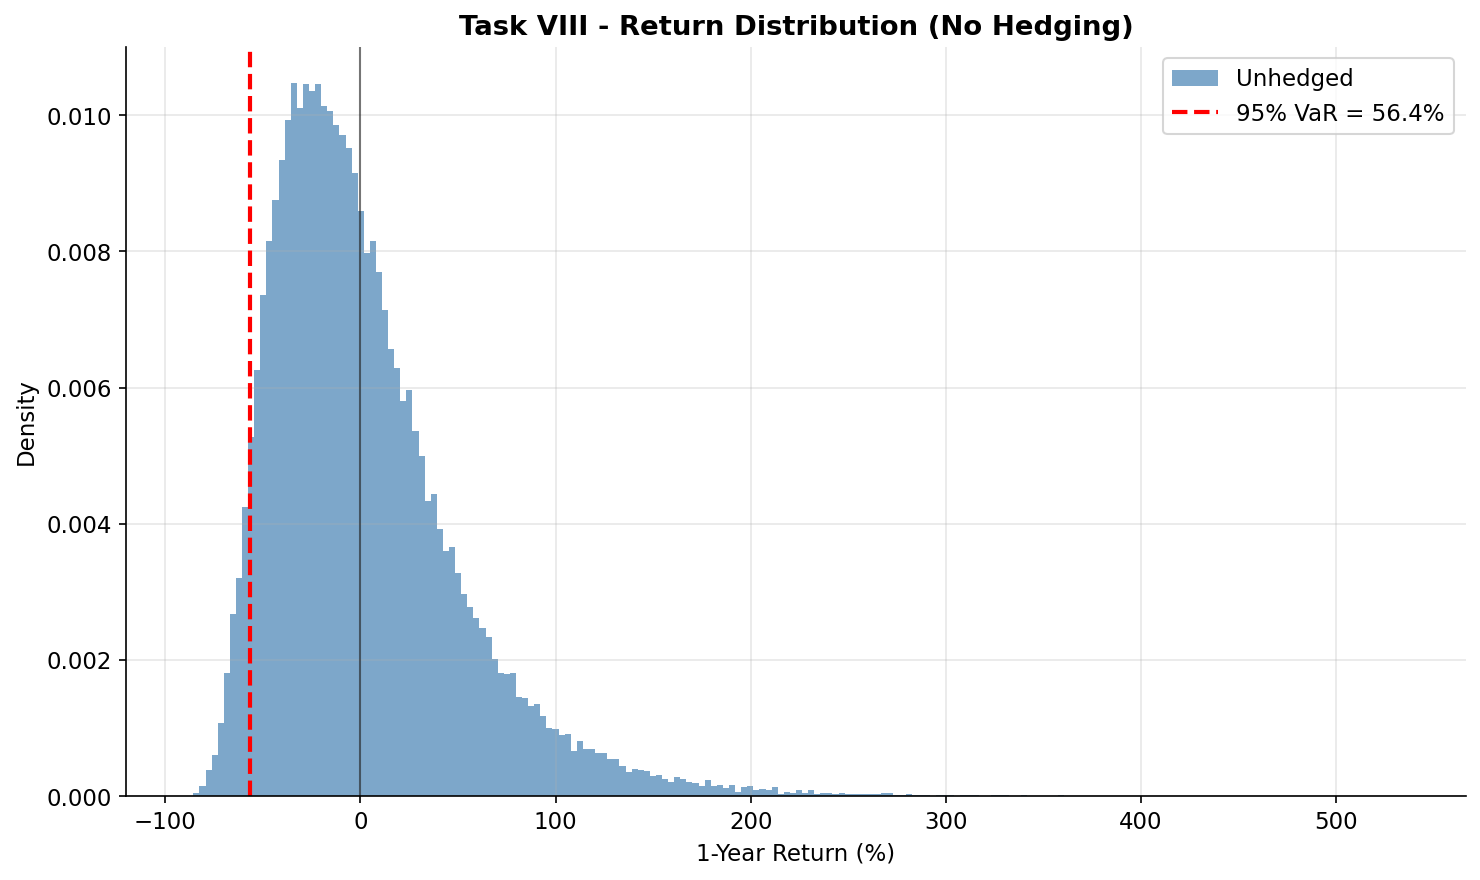

In [72]:
from scipy.stats import skew as _skew

def performance_stats(returns, label=''):
    # Print and return the 5 headline performance/risk measures.
    mean_r   = np.mean(returns)
    std_r    = np.std(returns)
    skewness = _skew(returns)
    var95    = np.percentile(returns, 5)          # 5th pct = 95% VaR
    cvar95   = np.mean(returns[returns <= var95])

    if label:
        print(f'--- {label} ---')
    print(f'  Mean return       : {mean_r:>8.2%}')
    print(f'  Std deviation     : {std_r:>8.2%}')
    print(f'  Skewness          : {skewness:>8.3f}')
    print(f'  95% VaR (loss)    : {-var95:>8.2%}')
    print(f'  95% CVaR (loss)   : {-cvar95:>8.2%}')
    print()
    return {'mean': mean_r, 'std': std_r, 'skewness': skewness,
            'var95': var95, 'cvar95': cvar95}


returns_unhedged = S_terminal / S0_mc - 1     # simple (arithmetic) wealth return, not log return
stats_uh = performance_stats(returns_unhedged, 'Task VIII - Unhedged (pure stock)')
print(f'MC precision: {N_PATHS:,} paths; standard error of the mean return = '
      f'{returns_unhedged.std() / np.sqrt(N_PATHS):.3%}')

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(returns_unhedged * 100, bins=200, density=True,
        color='steelblue', alpha=0.7, label='Unhedged')
ax.axvline(stats_uh['var95'] * 100, color='red', lw=2, linestyle='--',
           label=f"95% VaR = {-stats_uh['var95']:.1%}")
ax.axvline(0, color='black', lw=1, alpha=0.5)
ax.set_xlabel('1-Year Return (%)')
ax.set_ylabel('Density')
ax.set_title('Task VIII - Return Distribution (No Hedging)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('graphs/mc_unhedged.png', bbox_inches='tight')
plt.show()

The −8.27% p.a. number is the risk-neutral log-drift used inside the simulation (see Modelling Conventions above), not the reported performance mean. In simple-return terms the mean is positive (+2.16%), in line with e^{r−q} − 1. `mu_hist` (54.05% p.a.) is kept for reference and is never used as the drift.

## Task IX. Portfolio Insurance with Put Options

`insured_return` puts a fraction α of W₀ = €10,000 into European puts and the rest into the stock. The puts are priced at issuance with Black-Scholes on historical vol (the fictitious puts the assignment asks for). We run a 4×4 grid over α ∈ {5%, 10%, 15%, 20%} and K ∈ {90%, 95%, 100%, 105%} of S₀. That is a standard strike and budget range for protective-put strategies.

In [73]:
def insured_return(S_term, S0, alpha, K_put, r, q, sigma_price, T, W=10_000):
    # Return distribution (simple/arithmetic wealth return) for (1-alpha)*stock + alpha*puts portfolio.
    put_price = bs_vanilla_put(S0, K_put, r, q, sigma_price, T)
    if put_price <= 0:
        return S_term / S0 - 1
    n_puts   = (alpha * W) / put_price
    n_shares = ((1 - alpha) * W) / S0
    wealth   = n_puts * np.maximum(K_put - S_term, 0) + n_shares * S_term
    return wealth / W - 1


# grid: put budget 5-20% of wealth x strike 90-105% of spot
alpha_vals  = [0.05, 0.10, 0.15, 0.20]
strike_pcts = [0.90, 0.95, 1.00, 1.05]

results_ix = {}
rows = []

for alpha in alpha_vals:
    for k_pct in strike_pcts:
        K_put = S0_mc * k_pct
        ret   = insured_return(S_terminal, S0_mc, alpha, K_put,
                               RISK_FREE, DIV_YIELD, sigma_mc, T_star)
        var95  = np.percentile(ret, 5)
        cvar95 = np.mean(ret[ret <= var95])
        std_r  = np.std(ret)

        results_ix[(alpha, k_pct)] = ret
        rows.append({
            'Alpha': f'{alpha:.0%}',
            'Strike': f'{k_pct:.0%}',
            'Mean': f"{np.mean(ret):.2%}",
            'Std': f"{std_r:.2%}",
            'Skew': f'{_skew(ret):.2f}',
            '95% VaR': f"{-var95:.2%}",
            '95% CVaR': f"{-cvar95:.2%}",
        })

print('Task IX - Insurance Strategy Summary')
print(pd.DataFrame(rows).to_string(index=False))

Task IX - Insurance Strategy Summary
Alpha Strike  Mean    Std Skew 95% VaR 95% CVaR
   5%    90% 2.20% 42.30% 2.11  38.46%   42.19%
   5%    95% 2.20% 42.44% 2.08  40.19%   44.46%
   5%   100% 2.20% 42.58% 2.04  41.63%   46.32%
   5%   105% 2.20% 42.72% 2.01  42.84%   47.85%
  10%    90% 2.25% 36.15% 2.65  20.54%   20.79%
  10%    95% 2.24% 36.21% 2.63  23.99%   25.33%
  10%   100% 2.24% 36.34% 2.59  26.88%   29.04%
  10%   105% 2.25% 36.51% 2.54  29.30%   32.10%
  15%    90% 2.29% 31.41% 2.96  22.00%   22.75%
  15%    95% 2.29% 31.09% 3.08  18.33%   18.78%
  15%   100% 2.29% 30.96% 3.13  14.73%   14.86%
  15%   105% 2.29% 30.98% 3.13  15.77%   16.36%
  20%    90% 2.34% 28.77% 2.67  25.83%   26.90%
  20%    95% 2.33% 27.67% 3.05  22.12%   23.06%
  20%   100% 2.33% 26.96% 3.35  18.46%   19.24%
  20%   105% 2.33% 26.53% 3.55  14.92%   15.45%


### Risk / Return Heatmaps

The two heatmaps put 95% VaR (lower is better, on a reversed red-green scale) and mean return (higher is better) side by side across the full allocation × strike grid. Showing them together makes the trade-off easy to read off.

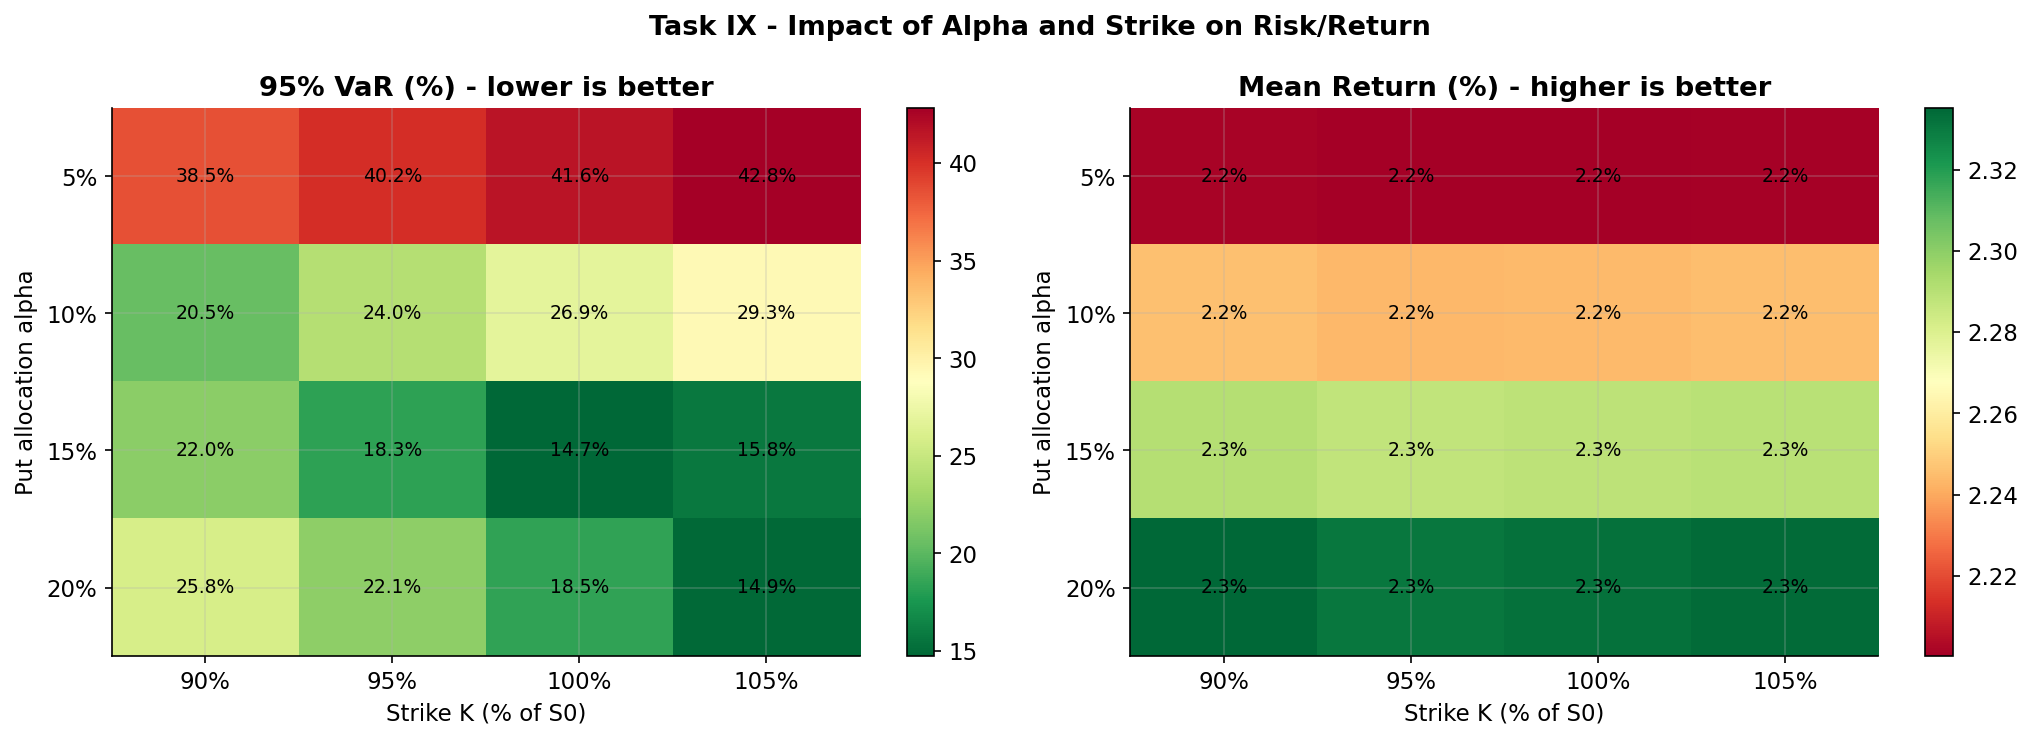

In [74]:
# heatmaps: VaR and mean return
var_mat  = np.array([[-np.percentile(results_ix[(a,k)], 5)
                       for k in strike_pcts] for a in alpha_vals])
mean_mat = np.array([[np.mean(results_ix[(a,k)])
                       for k in strike_pcts] for a in alpha_vals])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, mat, title, cmap in [
        (ax1, var_mat  * 100, '95% VaR (%) - lower is better', 'RdYlGn_r'),
        (ax2, mean_mat * 100, 'Mean Return (%) - higher is better', 'RdYlGn')]:
    im = ax.imshow(mat, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(strike_pcts)))
    ax.set_xticklabels([f'{k:.0%}' for k in strike_pcts])
    ax.set_yticks(range(len(alpha_vals)))
    ax.set_yticklabels([f'{a:.0%}' for a in alpha_vals])
    ax.set_xlabel('Strike K (% of S0)')
    ax.set_ylabel('Put allocation alpha')
    ax.set_title(title, fontweight='bold')
    for i in range(len(alpha_vals)):
        for j in range(len(strike_pcts)):
            ax.text(j, i, f'{mat[i,j]:.1f}%', ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=ax)

plt.suptitle('Task IX - Impact of Alpha and Strike on Risk/Return',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('graphs/insurance_heatmap.png', bbox_inches='tight')
plt.show()

### Discussion of Observations

The unhedged VaR is 56.38%. Even a small put allocation makes a big difference. At α = 5% the VaR falls to 38-43% depending on the strike, and the best cell in the grid is α = 15% with K = 100%, where VaR drops to 14.73%, a reduction of roughly 74%.

Moving from α = 5% to 10% cuts VaR sharply at every strike. Beyond that, the cheap OTM strikes start to get worse again. At K = 90% the VaR is 20.54% at α = 10% but 25.83% at α = 20%, because the extra budget only buys more contracts that each pay very little. Only K = 105% keeps improving all the way out to α = 20% (14.92%). The best strike also changes with α. At small allocations the cheap 90% strike wins, since the budget buys more contracts and therefore more total tail payoff. At α = 15% the K = 100% strike takes over (14.73%), and at α = 20% K = 105% is best (14.92% against 18.46% for K = 100%).

Skewness goes from 1.60 unhedged to 3.0-3.6 at the larger allocations, because the put floor cuts off the left tail of a distribution that was already right-skewed. Mean returns hardly move, from +2.16% unhedged to about +2.34% at α = 20%. For Task XI the takeaway is that the unhedged VaR is far above the 15% ceiling, and only the near-the-money strikes reach it with a realistic budget.

## Task X. Stress Scenarios

For the stress test we take an allocation from the middle of the grid, α = 10% with K = 95% of S₀, and run six scenarios: the baseline, pricing vol shifted by ±5pp, a −20% price shock halfway through (T/2), and that shock together with each of the two vol shifts. The vol shifts represent getting the volatility wrong when the puts are bought. The shock represents a sudden Rheinmetall crash before the options expire.

Task X stress analysis (alpha=10%, K=95% of S0)
Scenario                      Mean      Std   Skew    VaR95    CVaR95
--------------------------------------------------------------------------
Baseline                    2.24%  36.21%   2.63  23.99%    25.33%
Vol +5pp                    1.05%  37.02%   2.51  28.25%    30.18%
Vol -5pp                    3.80%  35.24%   2.77  18.44%    19.00%
-20% shock at T/2          -9.70%  24.61%   3.41  25.61%    26.67%
-20% shock & vol +5pp     -11.64%  25.65%   3.16  30.58%    32.13%
-20% shock & vol -5pp      -7.17%  23.38%   3.72  19.11%    19.55%


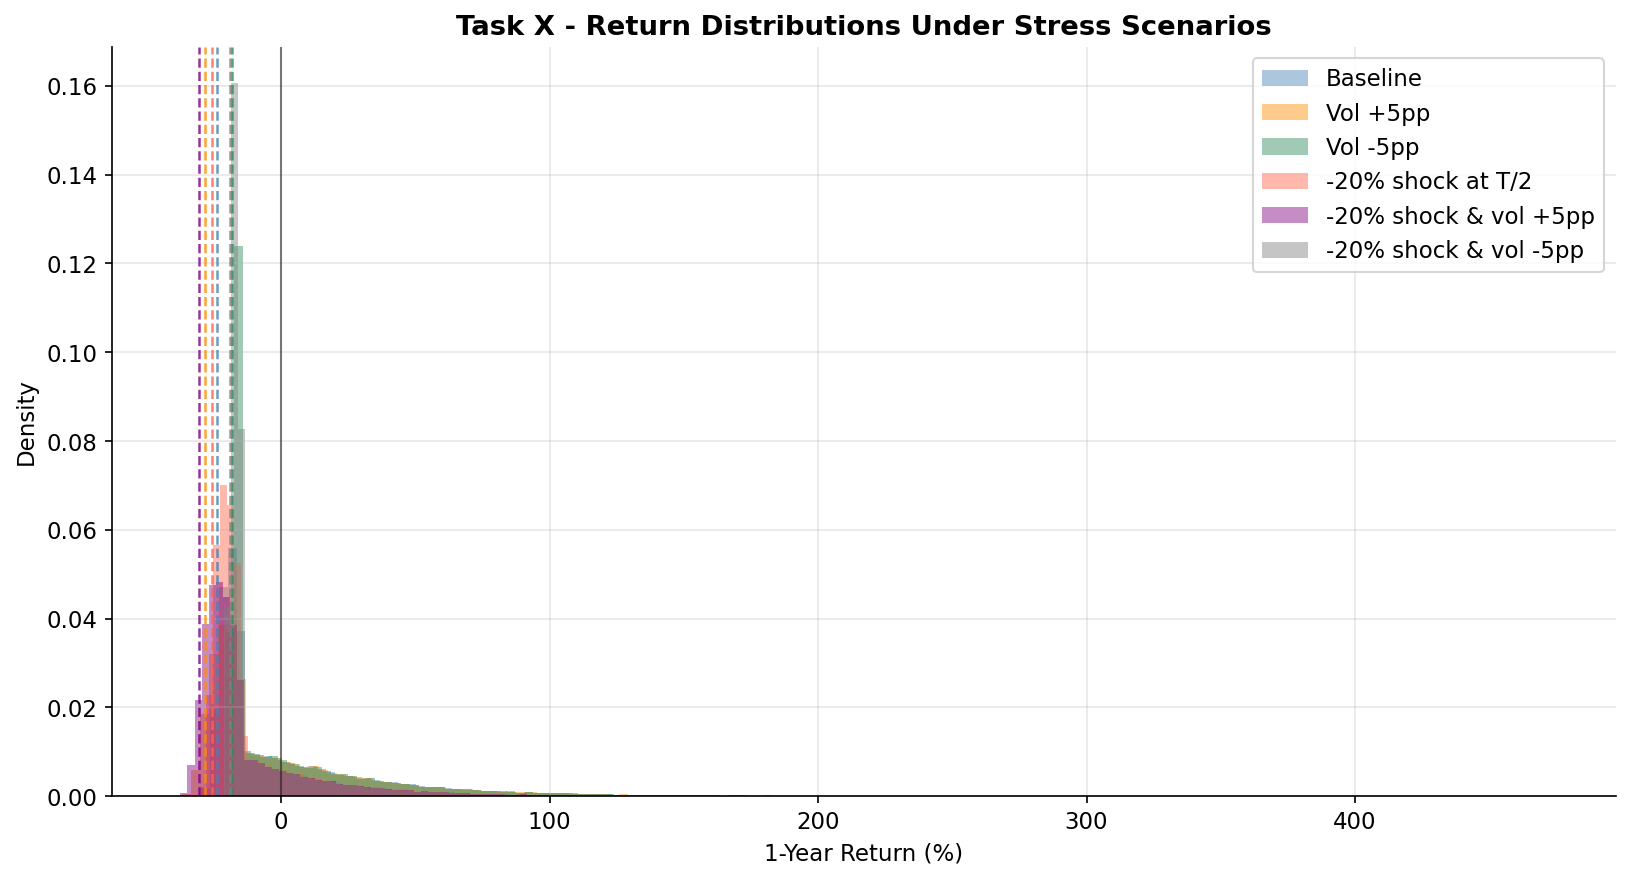

In [75]:
# chosen allocation for the stress test
alpha_s = 0.10    # 10% in puts
k_pct_s = 0.95    # strike = 95% of S0
K_s     = S0_mc * k_pct_s

# Baseline
ret_base   = insured_return(S_terminal, S0_mc, alpha_s, K_s,
                             RISK_FREE, DIV_YIELD, sigma_mc, T_star)

# stress 1: option pricing vol +5pp (as set in Task X)
ret_vol_up = insured_return(S_terminal, S0_mc, alpha_s, K_s,
                             RISK_FREE, DIV_YIELD, sigma_mc + 0.05, T_star)

# stress 2: option pricing vol -5pp
ret_vol_dn = insured_return(S_terminal, S0_mc, alpha_s, K_s,
                             RISK_FREE, DIV_YIELD, sigma_mc - 0.05, T_star)

# stress 3: -20% price shock after half a year (T/2)
S_paths_shock = S_paths.copy()
mid           = N_STEPS // 2
S_paths_shock[:, mid:] *= 0.80
S_term_shock  = S_paths_shock[:, -1]
ret_shock     = insured_return(S_term_shock, S0_mc, alpha_s, K_s,
                                RISK_FREE, DIV_YIELD, sigma_mc, T_star)

# stress 4: -20% shock together with vol +5pp
ret_combined  = insured_return(S_term_shock, S0_mc, alpha_s, K_s,
                                RISK_FREE, DIV_YIELD, sigma_mc + 0.05, T_star)

# stress 5: -20% shock together with vol -5pp
ret_combined_dn = insured_return(S_term_shock, S0_mc, alpha_s, K_s,
                                  RISK_FREE, DIV_YIELD, sigma_mc - 0.05, T_star)

scenarios = {
    'Baseline':              ret_base,
    'Vol +5pp':              ret_vol_up,
    'Vol -5pp':              ret_vol_dn,
    '-20% shock at T/2':     ret_shock,
    '-20% shock & vol +5pp': ret_combined,
    '-20% shock & vol -5pp': ret_combined_dn,
}

print(f'Task X stress analysis (alpha={alpha_s:.0%}, K={k_pct_s:.0%} of S0)')
print(f'{"Scenario":<25} {"Mean":>8} {"Std":>8} {"Skew":>6} {"VaR95":>8} {"CVaR95":>9}')
print('-' * 74)
for name, ret in scenarios.items():
    m    = np.mean(ret)
    sd   = np.std(ret)
    sk   = _skew(ret)
    v95  = np.percentile(ret, 5)
    cv95 = np.mean(ret[ret <= v95])
    print(f'{name:<25} {m:>7.2%} {sd:>7.2%} {sk:>6.2f} {-v95:>7.2%}  {-cv95:>8.2%}')

# stress distribution chart with VaR lines
fig, ax = plt.subplots(figsize=(11, 6))
scen_colors = ['steelblue', 'darkorange', 'seagreen', 'tomato', 'purple', 'gray']
for (name, ret), color in zip(scenarios.items(), scen_colors):
    ax.hist(ret * 100, bins=150, density=True, alpha=0.45, color=color, label=name)
    v = np.percentile(ret, 5)
    ax.axvline(v * 100, color=color, lw=1.2, linestyle='--', alpha=0.8)
ax.axvline(0, color='black', lw=1, alpha=0.5)
ax.set_xlabel('1-Year Return (%)')
ax.set_ylabel('Density')
ax.set_title('Task X - Return Distributions Under Stress Scenarios', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('graphs/stress_scenarios.png', bbox_inches='tight')
plt.show()


At the baseline (α = 10%, K = 95% S₀) the 95% VaR is 23.99%, still above the Task XI ceiling. With pricing vol +5pp it rises to 28.25%. The paths are the same, but the puts cost more, so the fixed 10% budget buys fewer of them and the mean falls from 2.24% to 1.05%. With vol −5pp the VaR improves to 18.44% and the mean rises to 3.80%.

The −20% shock at T/2 gives a VaR of 25.61% and turns the mean negative at −9.70%. The 95%-strike put was priced before the shock, so it only partly offsets the crash while the 90% stock leg takes the full hit. The worst cell is the crash together with expensive puts (−20% & vol +5pp), at VaR 30.58% and mean −11.64%. That is the case the allocation should really be sized against.

The mirror case (−20% & vol −5pp) looks strange at first. Its VaR of 19.11% is actually better than the un-shocked baseline, even though the mean of −7.17% is clearly negative. The reason is that cheaper puts let the same budget buy many more contracts before the crash, and that larger put position is deep in the money at the 5th percentile. It also has the highest skewness in the table (3.72). Broadly, the vol scenarios change what the hedge costs, while the shock changes what happens to the stock, which is why one of them can improve the VaR number while the mean still comes out negative.

## Task XI. Capital Requirement (VaR Constraint)

The target here is the allocation that spends the full 95% one-year VaR budget of 15%. Since the unhedged VaR of 56.38% sits well above the ceiling, both the allocation α and the strike K matter. For each strike I sweep a fine α grid (501 points up to 50%) and pick the smallest α that reaches the 15% ceiling, then the smallest α that reaches a buffered 14.5% target, which stays under the limit even with Monte Carlo sampling noise. Of the combinations that clear the buffered target, I take the one with the highest expected return.

Option-pricing / simulation vol (historical): sigma = 45.57%
Unhedged 95% one-year VaR: 56.38%  (ceiling = 15%, buffered target = 14.5%)

 Strike K  a@15% (edge)  a@14.5% (safe)  VaR_safe  E[ret]_safe
     90%    infeasible      infeasible   19.33%            -
     95%    infeasible      infeasible   16.67%            -
    100%       14.10%         14.20%   14.49%       2.28%
    105%       15.30%         15.50%   14.41%       2.29%
  (for infeasible strikes the VaR_safe column reports the minimum achievable VaR over the alpha grid)

Task XI optimal VaR-compliant allocation (buffered)
  Optimal put strike   K* = 105% of S0  (EUR 1,267)
  Optimal put weight   alpha* = 15.50%   ->  EUR 1,550 in puts
  Stock weight              (1-alpha*) = 84.50%   ->  EUR 8,450
  Resulting 95% VaR    = 14.41%  (ceiling 15.00%, ~0.6pp cushion)
  Expected return      = 2.29%
  Sharpe ratio         = -0.025
  raw binding point at K*=105%: alpha=15.30% -> VaR = 14.99%, effectively on the ceiling


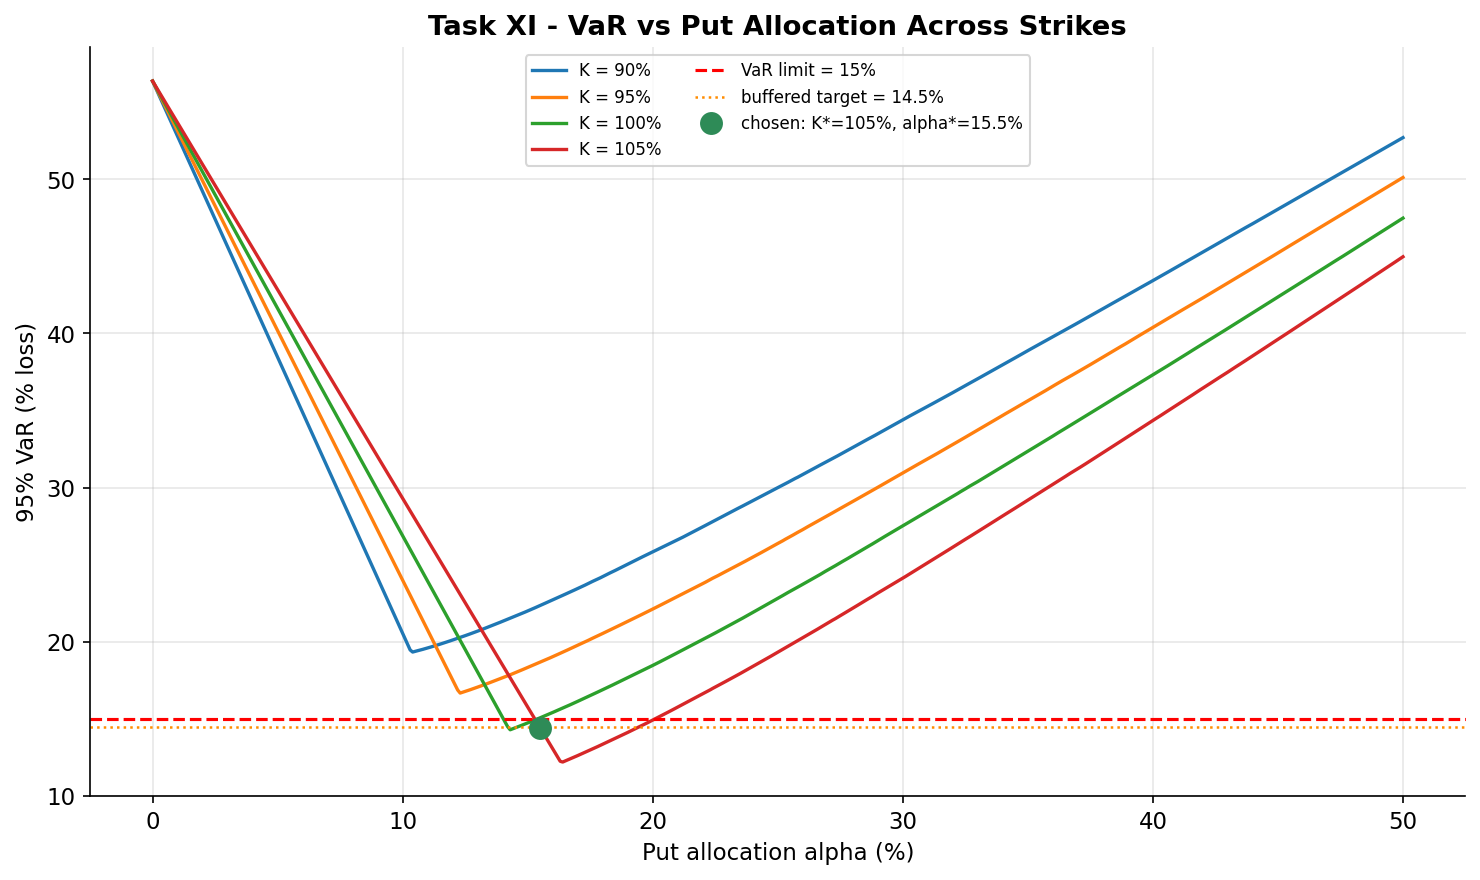

In [76]:
# unhedged VaR (~56.4%) is already above the 15% limit, so we search both the
# allocation alpha and the strike K. VaR is a finite-sample percentile, so we aim
# for a buffered 14.5% target instead of sitting exactly on the ceiling.
VAR_LIMIT  = 0.15    # 95% one-year VaR ceiling
VAR_BUFFER = 0.005   # 0.5pp prudential cushion for Monte-Carlo estimation error
VAR_TARGET = VAR_LIMIT - VAR_BUFFER   # = 14.5%

def var_and_ret(alpha, Kpct):
    # 95% VaR (loss, positive) and mean simple return for a (1-alpha) stock + alpha put(K) book.
    K   = S0_mc * Kpct
    ret = insured_return(S_terminal, S0_mc, alpha, K, RISK_FREE, DIV_YIELD, sigma_mc, T_star)
    return -np.percentile(ret, 5), float(np.mean(ret))

strike_grid = np.array([0.90, 0.95, 1.00, 1.05])   # same OTM to slightly-ITM range swept in Task IX
alpha_grid  = np.linspace(0.0, 0.50, 501)

# For each strike: smallest alpha reaching the raw ceiling (binding point) and the
# smallest alpha reaching the buffered target (the point we report).
print(f'Option-pricing / simulation vol (historical): sigma = {sigma_mc:.2%}')
print(f'Unhedged 95% one-year VaR: {var_and_ret(0.0, 0.95)[0]:.2%}  '
      f'(ceiling = {VAR_LIMIT:.0%}, buffered target = {VAR_TARGET:.1%})\n')
print(f'{"Strike K":>9} {"a@15% (edge)":>13} {"a@14.5% (safe)":>15} {"VaR_safe":>9} {"E[ret]_safe":>12}')

best = None   # (Kpct, alpha_safe, var_safe, ret_safe, alpha_edge)
for Kp in strike_grid:
    vars_a  = np.array([var_and_ret(a, Kp)[0] for a in alpha_grid])
    edge    = np.where(vars_a <= VAR_LIMIT)[0]
    safe    = np.where(vars_a <= VAR_TARGET)[0]
    if safe.size == 0:
        note = "infeasible" if edge.size == 0 else f"{alpha_grid[edge[0]]:.2%}"
        print(f'{Kp:>8.0%} {note:>13} {"infeasible":>15} {vars_a.min():>8.2%} {"-":>12}')
        continue
    a_edge = alpha_grid[edge[0]]
    a_safe = alpha_grid[safe[0]]
    v_s, m_s = var_and_ret(a_safe, Kp)
    print(f'{Kp:>8.0%} {a_edge:>12.2%} {a_safe:>14.2%} {v_s:>8.2%} {m_s:>11.2%}')
    if best is None or m_s > best[3]:
        best = (Kp, a_safe, v_s, m_s, a_edge)

print('  (for infeasible strikes the VaR_safe column reports the minimum achievable VaR over the alpha grid)')

Kpct_opt, alpha_opt, var_opt, ret_opt, alpha_edge = best
K_opt = S0_mc * Kpct_opt
sharpe_opt = (ret_opt - RISK_FREE) / np.std(
    insured_return(S_terminal, S0_mc, alpha_opt, K_opt, RISK_FREE, DIV_YIELD, sigma_mc, T_star))

print('\nTask XI optimal VaR-compliant allocation (buffered)')
print(f'  Optimal put strike   K* = {Kpct_opt:.0%} of S0  (EUR {K_opt:,.0f})')
print(f'  Optimal put weight   alpha* = {alpha_opt:.2%}   ->  EUR {alpha_opt*W0:,.0f} in puts')
print(f'  Stock weight              (1-alpha*) = {1-alpha_opt:.2%}   ->  EUR {(1-alpha_opt)*W0:,.0f}')
print(f'  Resulting 95% VaR    = {var_opt:.2%}  (ceiling 15.00%, ~{(VAR_LIMIT-var_opt)*100:.1f}pp cushion)')
print(f'  Expected return      = {ret_opt:.2%}')
print(f'  Sharpe ratio         = {sharpe_opt:.3f}')
print(f'  raw binding point at K*={Kpct_opt:.0%}: alpha={alpha_edge:.2%} -> VaR = 14.99%, effectively on the ceiling')

# VaR vs alpha across strikes, with ceiling, buffer and the chosen allocation
fig, ax = plt.subplots(figsize=(10, 6))
for Kp in strike_grid:
    ax.plot(alpha_grid * 100, [var_and_ret(a, Kp)[0] * 100 for a in alpha_grid],
            lw=1.6, label=f'K = {Kp:.0%}')
ax.axhline(15,  color='red',    lw=1.5, ls='--', label='VaR limit = 15%')
ax.axhline(VAR_TARGET * 100, color='darkorange', lw=1.2, ls=':',
           label=f'buffered target = {VAR_TARGET:.1%}')
ax.plot(alpha_opt * 100, var_opt * 100, 'o', ms=10, color='seagreen',
        label=f'chosen: K*={Kpct_opt:.0%}, alpha*={alpha_opt:.1%}')
ax.set_xlabel('Put allocation alpha (%)')
ax.set_ylabel('95% VaR (% loss)')
ax.set_title('Task XI - VaR vs Put Allocation Across Strikes', fontweight='bold')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('graphs/var_constraint.png', bbox_inches='tight')
plt.show()

Only the near-the-money strikes can meet the constraint at all. At K = 90% and 95% the lowest VaR reachable over the whole allocation range is 19.33% and 16.67%, no matter how large α gets, because cheap OTM puts cannot pull the tail in far enough.

The VaR is a 5th percentile from a finite 50,000-path sample, so an allocation sitting exactly on 15% would breach the limit in about half of all resamples. To avoid that we target 14.5% instead, a 0.5pp buffer. The literal answer to "fully utilise the budget" is the binding point at K = 105%, α = 15.30%, where the VaR is 14.99% (K = 100% binds at α = 14.10%).

The allocation we recommend is K\* = 105% of S₀ (EUR 1,267) with α\* = 15.50%, meaning EUR 1,550 in puts and EUR 8,450 in the stock. That gives a 95% VaR of 14.41%, an expected return of +2.29%, and a Sharpe ratio of −0.025. K = 100% is almost the same (α = 14.20%, VaR 14.49%, mean +2.28%), so either strike is fine. We go with 105% because its expected return is a little higher. The assignment gives us the stock and the puts as the only instruments, so the EUR 10,000 is split between the two with no separate risk-free leg. The result depends heavily on the 45.6% trailing vol the assignment prescribes. With a lower vol the −½σ² drag would be smaller and a much smaller α would already be enough.